In [3]:
from prefect.client.orchestration import get_client
from prefect.client.schemas.filters import (
    FlowRunFilter,
    FlowFilter,
    ArtifactFilter,
    ArtifactFilterFlowRunId,
)
from prefect.artifacts import Artifact
import json

total_video_haystack_ids = [
    "69d1f68d846a50051062bede",
    "69d1fa20846a50051062bee1",
    "69d204c5846a50051062bee7",
    "69d26461d1a79c20d403a99c",
    "69d26461d1a79c20d403a99d",
    "69d20b75846a50051062beea",
    "69d26461d1a79c20d403a99e",
    "69d20b75846a50051062beeb",
    "69d20f2a846a50051062beee",
    "69d20f2a846a50051062beef",
    "69d215d4d7ce9f0cd06950d9",
    "69d215d4d7ce9f0cd06950da",
    "69d1fa20846a50051062bee0",
    "69d1fe58846a50051062bee4",
    "69d21819d7ce9f0cd06950dd",
    "69d21f8bd7ce9f0cd06950df",
    "69d22274d7ce9f0cd06950e1",
    "69d22274d7ce9f0cd06950e2",
    "69d225e8d7ce9f0cd06950e5",
    "69d204c5846a50051062bee6",
    "69de2551ffb16b8fa0871109",
    "69d3bac406491d0fe176745a",
    "69d3cc4c06491d0fe1767460",
    "69d3cc4c06491d0fe1767462",
    "69d3dd1e06491d0fe176746d",
    "69d3d8b506491d0fe1767466",
    "69d3d8b506491d0fe1767467",
    "69d3dd1e06491d0fe176746c",
    "69d3d8b506491d0fe1767468",
    "69d3bac406491d0fe176745c",
    "69d39c6006491d0fe176744f",
    "69d3cc4c06491d0fe1767461",
    "69d3bac406491d0fe176745b",
    "69d3aba406491d0fe1767456",
    "69d3aba406491d0fe1767454",
    "69d39c6006491d0fe1767450",
    "69d3aba406491d0fe1767455",
    "69d392f406491d0fe1767448",
    "69d392f406491d0fe1767449",
    "69d392f406491d0fe176744a",
    "69d39c6006491d0fe176744e",
    "69d3674706491d0fe176742c",
    "69d29494d1a79c20d403a9a6",
    "69d36be106491d0fe176742e",
    "69d35e8706491d0fe1767424",
    "69d29494d1a79c20d403a9a7",
    "69d38f2306491d0fe1767444",
    "69d37da206491d0fe1767435",
    "69d3789006491d0fe1767431",
    "69d37da206491d0fe1767434",
    "69d38f2306491d0fe1767445",
    "69d3653106491d0fe176742a",
    "69d3899e06491d0fe176743f",
    "69d3835706491d0fe176743a",
    "69d3899e06491d0fe1767440",
    "69d28db8d1a79c20d403a9a3",
    "69d3899e06491d0fe176743e",
    "69d28db8d1a79c20d403a9a2",
    "69d3789006491d0fe1767430",
    "69d3835706491d0fe1767439",
    "69d3835706491d0fe1767438"
]


async def find_flow_runs_for_videos(video_ids: list[str]) -> dict[str, list[str]]:
    """Find flow runs that processed each video ID by searching flow run parameters."""
    async with get_client() as client:
        video_to_runs = {vid: [] for vid in video_ids}

        offset = 0
        limit = 200

        while True:
            runs = await client.read_flow_runs(
                flow_filter=FlowFilter(),  # optional: refine this if needed
                offset=offset,
                limit=limit,
            )

            if not runs:
                break

            for run in runs:
                params = run.parameters or {}
                run_video_id = params.get("video_id")

                if run_video_id in video_to_runs:
                    video_to_runs[run_video_id].append(str(run.id))

            offset += limit

        return video_to_runs


async def get_artifacts_for_flow_run(flow_run_id: str) -> list:
    """Get all artifacts for a specific flow run."""
    async with get_client() as client:
        artifacts = await client.read_artifacts(
            artifact_filter=ArtifactFilter(
                flow_run_id=ArtifactFilterFlowRunId(any_=[flow_run_id])
            )
        )
        return artifacts


# ---- RUN ----

print("Step 1: Finding flow runs for each video ID...")
video_to_flow_runs = await find_flow_runs_for_videos(total_video_haystack_ids)

found_count = sum(1 for v in video_to_flow_runs.values() if len(v) > 0)
print(f"Found flow runs for {found_count}/{len(total_video_haystack_ids)} videos")

for vid, runs in video_to_flow_runs.items():
    if runs:
        print(f"  {vid}: {len(runs)} run(s)")

Step 1: Finding flow runs for each video ID...
Found flow runs for 60/61 videos
  69d1f68d846a50051062bede: 1 run(s)
  69d1fa20846a50051062bee1: 1 run(s)
  69d204c5846a50051062bee7: 1 run(s)
  69d26461d1a79c20d403a99c: 1 run(s)
  69d26461d1a79c20d403a99d: 1 run(s)
  69d20b75846a50051062beea: 1 run(s)
  69d26461d1a79c20d403a99e: 1 run(s)
  69d20b75846a50051062beeb: 1 run(s)
  69d20f2a846a50051062beee: 1 run(s)
  69d20f2a846a50051062beef: 1 run(s)
  69d215d4d7ce9f0cd06950d9: 1 run(s)
  69d215d4d7ce9f0cd06950da: 1 run(s)
  69d1fa20846a50051062bee0: 1 run(s)
  69d1fe58846a50051062bee4: 1 run(s)
  69d21819d7ce9f0cd06950dd: 1 run(s)
  69d21f8bd7ce9f0cd06950df: 1 run(s)
  69d22274d7ce9f0cd06950e1: 1 run(s)
  69d22274d7ce9f0cd06950e2: 1 run(s)
  69d225e8d7ce9f0cd06950e5: 1 run(s)
  69d204c5846a50051062bee6: 1 run(s)
  69d3bac406491d0fe176745a: 1 run(s)
  69d3cc4c06491d0fe1767460: 1 run(s)
  69d3cc4c06491d0fe1767462: 1 run(s)
  69d3dd1e06491d0fe176746d: 1 run(s)
  69d3d8b506491d0fe1767466: 1 ru

In [4]:
print("Step 2: Fetching artifacts for each flow run...")

video_to_artifacts = {}

for video_id, flow_run_ids in video_to_flow_runs.items():
    if not flow_run_ids:
        continue
    
    all_artifacts = []
    for run_id in flow_run_ids:
        artifacts = await get_artifacts_for_flow_run(run_id)
        artifact_dict = [artifact.model_dump() for artifact in artifacts]
        all_artifacts.extend(artifact_dict)
    
    video_to_artifacts[video_id] = all_artifacts
    print(f"  {video_id}: {len(all_artifacts)} artifact(s)")

print(f"\nTotal: {sum(len(a) for a in video_to_artifacts.values())} artifacts across {len(video_to_artifacts)} videos")

Step 2: Fetching artifacts for each flow run...
  69d1f68d846a50051062bede: 43 artifact(s)
  69d1fa20846a50051062bee1: 43 artifact(s)
  69d204c5846a50051062bee7: 43 artifact(s)
  69d26461d1a79c20d403a99c: 44 artifact(s)
  69d26461d1a79c20d403a99d: 45 artifact(s)
  69d20b75846a50051062beea: 44 artifact(s)
  69d26461d1a79c20d403a99e: 48 artifact(s)
  69d20b75846a50051062beeb: 44 artifact(s)
  69d20f2a846a50051062beee: 44 artifact(s)
  69d20f2a846a50051062beef: 43 artifact(s)
  69d215d4d7ce9f0cd06950d9: 43 artifact(s)
  69d215d4d7ce9f0cd06950da: 43 artifact(s)
  69d1fa20846a50051062bee0: 45 artifact(s)
  69d1fe58846a50051062bee4: 42 artifact(s)
  69d21819d7ce9f0cd06950dd: 43 artifact(s)
  69d21f8bd7ce9f0cd06950df: 42 artifact(s)
  69d22274d7ce9f0cd06950e1: 43 artifact(s)
  69d22274d7ce9f0cd06950e2: 42 artifact(s)
  69d225e8d7ce9f0cd06950e5: 42 artifact(s)
  69d204c5846a50051062bee6: 42 artifact(s)
  69d3bac406491d0fe176745a: 46 artifact(s)
  69d3cc4c06491d0fe1767460: 42 artifact(s)
  69d3

In [5]:
len(video_to_artifacts['69d1f68d846a50051062bede'])

43

In [6]:
import re
from typing import Dict, Any

def filter_final_markdown(element: dict):
    return element['key'] is None and "# Video Processing Complete" in element['data']


def parse_markdown_artifact(data: str) -> Dict[str, Any]:
    result: Dict[str, Any] = {}

    def parse_key_value_lines(section: str):
        kv = {}
        matches = re.findall(r"\*\*(.*?)\*\*:\s*`?(.*?)`?\n", section)
        for k, v in matches:
            kv[k.strip()] = v.strip()
        return kv

    def parse_table(section: str):
        lines = [l.strip() for l in section.splitlines() if "|" in l]
        if len(lines) < 3:
            return []

        headers = [h.strip() for h in lines[0].strip("|").split("|")]
        rows = []

        for line in lines[2:]:
            values = [v.strip().strip("`") for v in line.strip("|").split("|")]
            if len(values) != len(headers):
                continue
            rows.append(dict(zip(headers, values)))

        return rows

    def extract_section(title: str):
        pattern = rf"## {re.escape(title)}(.*?)(\n## |\Z)"
        match = re.search(pattern, data, re.S)
        return match.group(1).strip() if match else ""

    # ----------- top metadata -----------

    result["summary"] = parse_key_value_lines(data)

    # ----------- Artifact Summary -----------

    artifact_section = extract_section("Artifact Summary")
    result["artifact_summary"] = parse_table(artifact_section)

    # ----------- LLM Cost Breakdown -----------

    llm_section = extract_section("LLM Cost Breakdown by Stage")
    result["llm_cost_breakdown"] = parse_table(llm_section)

    # ----------- Knowledge Graph Pipeline -----------

    kg_section = extract_section("Knowledge Graph Pipeline")

    def extract_subtable(title):
        pattern = rf"### {re.escape(title)}(.*?)(\n### |\Z)"
        match = re.search(pattern, kg_section, re.S)
        return parse_table(match.group(1)) if match else []

    result["kg"] = {
        "entity_stats": extract_subtable("Entity Statistics"),
        "event_layer": extract_subtable("Event Layer"),
        "community_structure": extract_subtable("Community Structure"),
        "llm_usage": extract_subtable("LLM Cost & Usage"),
    }

    # ----------- Timing -----------

    timing_section = extract_section("Timing Breakdown")
    result["timing"] = parse_table(timing_section)

    return result


In [7]:
sample_list_artifacts = video_to_artifacts['69d1f68d846a50051062bede']

final_artifact = next(filter(filter_final_markdown, sample_list_artifacts))

In [8]:
parse_markdown_artifact(final_artifact['data'])

{'summary': {},
 'artifact_summary': [{'Artifact': 'Shots', 'Count': '159'},
  {'Artifact': 'ASR Artifacts', 'Count': '159'},
  {'Artifact': 'Audio Segments', 'Count': '7'},
  {'Artifact': 'Segment Embeddings (Multimodal)', 'Count': '7'},
  {'Artifact': 'Segment Captions', 'Count': '7'},
  {'Artifact': 'Audio Transcript Embeddings', 'Count': '7'},
  {'Artifact': 'Segment Caption Text Embeddings', 'Count': '7'},
  {'Artifact': 'Image Artifacts', 'Count': '795'},
  {'Artifact': 'Caption Artifacts', 'Count': '795'},
  {'Artifact': 'Image Embeddings (Multimodal)', 'Count': '795'},
  {'Artifact': 'OCR Artifacts', 'Count': '795'},
  {'Artifact': 'OCR Elasticsearch Documents', 'Count': '599'},
  {'Artifact': 'Caption Text Embeddings', 'Count': '795'},
  {'Artifact': 'Image Qdrant Points', 'Count': '795'},
  {'Artifact': 'Image Caption Qdrant Points', 'Count': '795'},
  {'Artifact': 'Segment Qdrant Points', 'Count': '7'},
  {'Artifact': 'Segment Caption Qdrant Points', 'Count': '7'},
  {'Artif

In [9]:
import pandas as pd
import re

# ---- Collect parsed data for all videos ----

all_parsed = {}

for video_id, artifacts in video_to_artifacts.items():
    final = next(filter(filter_final_markdown, artifacts), None)
    if final:
        all_parsed[video_id] = parse_markdown_artifact(final['data'])
    else:
        print(f"WARNING: No final markdown for {video_id}")

print(f"Parsed {len(all_parsed)}/{len(video_to_artifacts)} videos")

Parsed 60/60 videos


In [10]:
import pandas as pd
import re

def clean_num(s):
    if s is None:
        return None
    s = str(s)
    s = re.sub(r"\s*if\s+\w+\s*>?\s*0?\s*else\s*['\"]N/A['\"]", "", s)
    s = s.replace(',', '').replace('**', '').replace('`', '').strip()
    s = s.rstrip('`').rstrip("'")
    try:
        return float(s)
    except ValueError:
        return s

def extract_cost(s):
    if s is None:
        return None
    s = str(s)
    s = re.sub(r"\s*if\s+\w+\s*>?\s*0?\s*else\s*['\"]N/A['\"]", "", s)
    s = s.replace(',', '').replace('**', '').replace('`', '').replace('$', '').strip()
    try:
        return float(s)
    except ValueError:
        return None

# ========== 1. TIMING DATAFRAME ==========

timing_rows = []
for vid, parsed in all_parsed.items():
    for row in parsed.get('timing', []):
        stage = row.get('Stage', '').replace('**', '').strip()
        dur = clean_num(row.get('Duration (s)'))
        timing_rows.append({
            'video_id': vid,
            'stage': stage,
            'duration_s': dur,
        })

df_timing = pd.DataFrame(timing_rows)
df_timing_pivot = df_timing.pivot(index='video_id', columns='stage', values='duration_s')

print("=== Timing per video (seconds) ===")
display(df_timing_pivot.head(10))

# ========== 2. COST DATAFRAME ==========

cost_rows = []
for vid, parsed in all_parsed.items():
    for row in parsed.get('llm_cost_breakdown', []):
        stage = row.get('Stage', '').replace('**', '').strip()
        cost_rows.append({
            'video_id': vid,
            'stage': stage,
            'input_tokens': clean_num(row.get('Input Tokens')),
            'output_tokens': clean_num(row.get('Output Tokens')),
            'cost': extract_cost(row.get('Cost')),
        })

df_cost = pd.DataFrame(cost_rows)
df_cost_total = df_cost[df_cost['stage'] == 'TOTAL'].copy()
df_cost_stages = df_cost[df_cost['stage'] != 'TOTAL'].copy()

cost_pivot = df_cost_stages.pivot_table(
    index='video_id', columns='stage', values='cost', aggfunc='first'
)

print("\n=== LLM Cost per video ($) ===")
display(cost_pivot.head(10))

print(f"\nTotal LLM cost: ${df_cost_total['cost'].sum():.4f}")
print(f"Avg cost per video: ${df_cost_total['cost'].mean():.4f}")

# ========== 3. ARTIFACT COUNTS DATAFRAME ==========

artifact_rows = []
for vid, parsed in all_parsed.items():
    for row in parsed.get('artifact_summary', []):
        artifact_rows.append({
            'video_id': vid,
            'artifact_type': row.get('Artifact', ''),
            'count': clean_num(row.get('Count')),
        })

df_artifacts = pd.DataFrame(artifact_rows)
df_artifacts_pivot = df_artifacts.pivot_table(
    index='video_id', columns='artifact_type', values='count', aggfunc='first'
)

print("\n=== Artifact counts per video ===")
display(df_artifacts_pivot.head(10))

# ========== 4. KG STATS DATAFRAME ==========

kg_rows = []
for vid, parsed in all_parsed.items():
    kg = parsed.get('kg', {})
    for section_name, section_rows in kg.items():
        for row in section_rows:
            field = row.get('Field', row.get('Field', '')).replace('**', '').strip()
            val = row.get('Count', row.get('Value', ''))
            kg_rows.append({
                'video_id': vid,
                'kg_section': section_name,
                'field': field,
                'value': clean_num(val),
            })

df_kg = pd.DataFrame(kg_rows)
df_kg_pivot = df_kg.pivot_table(
    index='video_id', columns='field', values='value', aggfunc='first'
)

# print("\n=== KG stats per video ===")
# df_kg = df_kg[df_kg['field'] == 'Completion Tokens']['value'].apply(lambda x: x.replace(" if kg_completion_tokens > 0 else 'N/A'", ''))

display(df_kg_pivot.head(10))

# ========== 5. SUMMARY PER VIDEO ==========

summary_rows = []
for vid in all_parsed:
    total_row = df_cost_total[df_cost_total['video_id'] == vid]
    total_row_data = df_timing[df_timing['video_id'] == vid]
    total_dur = total_row_data[total_row_data['stage'] == 'Total']['duration_s'].values
    total_dur = total_dur[0] if len(total_dur) > 0 else None

    summary_rows.append({
        'video_id': vid,
        'total_cost': total_row['cost'].values[0] if len(total_row) > 0 else None,
        'total_duration_s': total_dur,
        'total_tokens': df_cost_total[df_cost_total['video_id'] == vid]['input_tokens'].values[0] if len(total_row) > 0 else None,
        'num_prefect_artifacts': len(video_to_artifacts.get(vid, [])),
    })

df_summary = pd.DataFrame(summary_rows)

print("\n=== Summary per video ===")
display(df_summary.head(10))

print(f"\nTotal cost across all videos: ${df_summary['total_cost'].sum():.4f}")
print(f"Avg duration: {df_summary['total_duration_s'].mean():.1f}s")

=== Timing per video (seconds) ===


stage,ASR,ArangoDB Indexing,Audio Segmentation,Audio Transcript Embedding,Audio Transcript Qdrant Indexing,Image Caption + OCR,Image Caption Embedding,Image Caption Qdrant Indexing,Image Embedding,Image Extraction,...,OCR Indexing,Segment Caption,Segment Caption Embedding,Segment Caption Qdrant Indexing,Segment Embedding,Segment Qdrant Indexing,Shot Detection,Total,Video Preprocessing,Video Registration
video_id,,,,,,,,,,,,,,,,,,,,,
69d1f68d846a50051062bede,19.62,3.08,3.80,1.28,0.87,207.76,61.69,55.95,183.68,8.80,...,13.33,3.97,0.56,0.79,7.75,0.85,8.02,699.91,7.31,5.01
69d1fa20846a50051062bee0,90.57,12.27,8.99,4.49,1.25,941.44,1029.02,571.60,1068.09,54.05,...,202.13,6.69,1.29,1.19,18.17,1.07,19.07,4882.17,45.06,5.37
69d1fa20846a50051062bee1,19.14,3.59,3.91,1.23,0.98,203.98,58.72,41.30,182.12,10.19,...,7.76,3.92,0.71,1.02,8.50,0.78,8.06,697.04,9.53,4.99
69d1fe58846a50051062bee4,18.92,2.84,15.96,1.19,0.69,296.49,61.62,73.39,190.78,10.37,...,11.06,26.28,0.48,0.59,6.41,0.62,8.32,835.53,7.57,4.72
69d204c5846a50051062bee6,13.79,1.02,5.84,2.21,0.64,5.48,7.47,7.49,31.39,3.42,...,1.27,9.31,17.82,0.63,73.72,0.34,16.19,219.81,1.36,6.08
69d204c5846a50051062bee7,31.66,4.75,4.05,2.51,1.21,150.30,140.88,251.73,263.30,14.17,...,23.88,3.92,36.96,1.32,45.73,0.76,14.79,1085.30,11.00,5.80
69d20b75846a50051062beea,10.95,6.32,1.90,10.12,6.99,100.02,136.37,36.24,93.82,7.94,...,3.31,9.01,8.56,9.55,19.74,1.19,13.13,656.21,5.16,8.36
69d20b75846a50051062beeb,24.51,6.68,4.11,7.51,5.42,125.45,39.44,29.79,139.83,9.46,...,30.37,5.07,7.44,4.48,18.95,3.65,11.74,728.91,7.98,8.09
69d20f2a846a50051062beee,22.19,4.28,3.68,1.25,1.00,171.58,64.71,47.59,223.22,9.88,...,71.64,13.05,0.86,0.73,11.24,0.72,8.59,758.09,7.88,5.13



=== LLM Cost per video ($) ===


stage,Audio Segmentation,Image Caption + OCR,KG Pipeline,Segment Caption
video_id,,,,
69d1f68d846a50051062bede,0.000550,0.212549,0.033172,0.002016
69d1fa20846a50051062bee0,0.001853,1.107651,0.175011,0.005934
69d1fa20846a50051062bee1,0.000558,0.200711,0.043372,0.002033
69d1fe58846a50051062bee4,0.000518,0.224405,0.024640,0.001470
69d204c5846a50051062bee6,0.000431,0.024245,0.001051,0.000802
69d204c5846a50051062bee7,0.000707,0.259925,0.013729,0.002216
69d20b75846a50051062beea,0.000125,0.088474,0.010483,0.002551
69d20b75846a50051062beeb,0.000573,0.148091,0.035668,0.002936
69d20f2a846a50051062beee,0.000636,0.230159,0.023761,0.002951



Total LLM cost: $10.4094
Avg cost per video: $0.1735

=== Artifact counts per video ===


artifact_type,ASR Artifacts,Audio Segments,Audio Transcript Embeddings,Audio Transcript Qdrant Points,Caption Artifacts,Caption Text Embeddings,Image Artifacts,Image Caption Qdrant Points,Image Embeddings (Multimodal),Image Qdrant Points,OCR Artifacts,OCR Elasticsearch Documents,Segment Caption Qdrant Points,Segment Caption Text Embeddings,Segment Captions,Segment Embeddings (Multimodal),Segment Qdrant Points,Shots
video_id,,,,,,,,,,,,,,,,,,
69d1f68d846a50051062bede,159.0,7.0,7.0,7.0,795.0,795.0,795.0,795.0,795.0,795.0,795.0,599.0,7.0,7.0,7.0,7.0,7.0,159.0
69d1fa20846a50051062bee0,866.0,19.0,19.0,19.0,4330.0,4330.0,4330.0,4330.0,4330.0,4330.0,4330.0,944.0,19.0,19.0,19.0,19.0,19.0,866.0
69d1fa20846a50051062bee1,155.0,7.0,7.0,7.0,770.0,770.0,770.0,770.0,770.0,770.0,770.0,27.0,7.0,7.0,7.0,7.0,7.0,155.0
69d1fe58846a50051062bee4,166.0,5.0,5.0,5.0,830.0,830.0,830.0,830.0,830.0,830.0,830.0,382.0,5.0,5.0,5.0,5.0,5.0,166.0
69d204c5846a50051062bee6,17.0,2.0,2.0,2.0,85.0,85.0,85.0,85.0,85.0,85.0,85.0,73.0,2.0,2.0,2.0,2.0,2.0,17.0
69d204c5846a50051062bee7,208.0,7.0,7.0,7.0,1040.0,1040.0,1040.0,1040.0,1040.0,1040.0,1040.0,630.0,7.0,7.0,7.0,7.0,7.0,208.0
69d20b75846a50051062beea,69.0,11.0,11.0,11.0,345.0,345.0,345.0,345.0,345.0,345.0,345.0,15.0,11.0,11.0,11.0,11.0,11.0,69.0
69d20b75846a50051062beeb,117.0,11.0,11.0,11.0,585.0,585.0,585.0,585.0,585.0,585.0,585.0,269.0,11.0,11.0,11.0,11.0,11.0,117.0
69d20f2a846a50051062beee,179.0,11.0,11.0,11.0,895.0,895.0,895.0,895.0,895.0,895.0,895.0,623.0,11.0,11.0,11.0,11.0,11.0,179.0


field,Big Events,Canonical Entities (resolved),Communities Detected,Completion Tokens,Entity Resolution Ratio,Estimated Cost,Event-to-Event Edges,Global Relationships,Graph Modularity,LLM Calls,LLM Model,Micro-Event Edges,Micro-Events,Nodes with Node2Vec Embeddings,Prompt Tokens,Raw Entities (extracted)
video_id,,,,,,,,,,,,,,,,
69d1f68d846a50051062bede,7.0,24.0,4.0,28939.0,1.62x,$0.0332,21.0,80.0,0.3193,358.0,google/gemini-2.5-flash-lite,636.0,59.0,94.0,215966.0,39.0
69d1fa20846a50051062bee0,19.0,139.0,30.0,140185.0,1.29x,$0.1750,167.0,224.0,0.7626,2037.0,google/gemini-2.5-flash-lite,2383.0,200.0,388.0,1189371.0,179.0
69d1fa20846a50051062bee1,7.0,25.0,6.0,34695.0,1.88x,$0.0434,21.0,69.0,0.347,488.0,google/gemini-2.5-flash-lite,663.0,68.0,106.0,294938.0,47.0
69d1fe58846a50051062bee4,5.0,29.0,3.0,21980.0,1.59x,$0.0246,10.0,55.0,0.3153,256.0,google/gemini-2.5-flash-lite,450.0,43.0,80.0,158480.0,46.0
69d204c5846a50051062bee6,2.0,5.0,1.0,1495.0,1.40x,$0.0011,1.0,9.0,0.0,4.0,google/gemini-2.5-flash-lite,72.0,17.0,25.0,4526.0,7.0
69d204c5846a50051062bee7,7.0,22.0,4.0,15192.0,2.00x,$0.0137,21.0,81.0,0.2029,116.0,google/gemini-2.5-flash-lite,760.0,63.0,96.0,76524.0,44.0
69d20b75846a50051062beea,11.0,25.0,4.0,13732.0,2.76x,$0.0105,55.0,82.0,0.2106,64.0,google/gemini-2.5-flash-lite,424.0,52.0,92.0,49898.0,69.0
69d20b75846a50051062beeb,11.0,20.0,5.0,31630.0,3.20x,$0.0357,55.0,76.0,0.2655,375.0,google/gemini-2.5-flash-lite,984.0,84.0,120.0,230158.0,64.0
69d20f2a846a50051062beee,11.0,27.0,5.0,23991.0,2.67x,$0.0238,55.0,98.0,0.272,217.0,google/gemini-2.5-flash-lite,824.0,75.0,118.0,141643.0,72.0



=== Summary per video ===


,video_id,total_cost,total_duration_s,total_tokens,num_prefect_artifacts
0,69d1f68d846a50051062bede,0.248287,699.91,2063201.0,43
1,69d1fa20846a50051062bee1,0.246675,697.04,2091114.0,43
2,69d204c5846a50051062bee7,0.276577,1085.30,2500086.0,43
3,69d26461d1a79c20d403a99c,0.280491,4112.31,1499006.0,44
4,69d26461d1a79c20d403a99d,0.742142,8356.44,4770309.0,45
5,69d20b75846a50051062beea,0.101633,656.21,867440.0,44
6,69d26461d1a79c20d403a99e,0.895393,8953.38,5764946.0,48
7,69d20b75846a50051062beeb,0.187268,728.91,1605806.0,44
8,69d20f2a846a50051062beee,0.257507,758.09,2226718.0,44
9,69d20f2a846a50051062beef,0.148621,638.21,1296331.0,43



Total cost across all videos: $10.4094
Avg duration: 1041.6s


In [11]:
# ====== MASTER DATAFRAME: one row per video ======

master_rows = []

for vid in all_parsed:
    row = {'video_id': vid}
    parsed = all_parsed[vid]

    # Timing
    for t in parsed.get('timing', []):
        stage = t.get('Stage', '').replace('**', '').strip()
        dur = t.get('Duration (s)', '0')
        dur = re.sub(r"\s*if\s+\w+\s*>\s*0\s*else\s*['\"]N/A['\"]", "", str(dur))
        dur = dur.replace(',', '').replace('**', '').replace('`', '').strip()
        try:
            row[f'timing_{stage}'] = float(dur)
        except:
            row[f'timing_{stage}'] = None

    # Cost
    for c in parsed.get('llm_cost_breakdown', []):
        stage = c.get('Stage', '').replace('**', '').strip()
        cost = c.get('Cost', '0')
        cost = re.sub(r"\s*if\s+\w+\s*>\s*0\s*else\s*['\"]N/A['\"]", "", str(cost))
        cost = cost.replace(',', '').replace('**', '').replace('`', '').replace('$', '').strip()
        try:
            row[f'cost_{stage}'] = float(cost)
        except:
            row[f'cost_{stage}'] = None

        inp = c.get('Input Tokens', '0')
        inp = re.sub(r"\s*if\s+\w+\s*>\s*0\s*else\s*['\"]N/A['\"]", "", str(inp))
        inp = inp.replace(',', '').replace('**', '').replace('`', '').strip()
        try:
            row[f'tokens_in_{stage}'] = float(inp)
        except:
            row[f'tokens_in_{stage}'] = None

        out = c.get('Output Tokens', '0')
        out = re.sub(r"\s*if\s+\w+\s*>\s*0\s*else\s*['\"]N/A['\"]", "", str(out))
        out = out.replace(',', '').replace('**', '').replace('`', '').strip()
        try:
            row[f'tokens_out_{stage}'] = float(out)
        except:
            row[f'tokens_out_{stage}'] = None

        calls = c.get('LLM Calls', '0')
        calls = re.sub(r"\s*if\s+\w+\s*>\s*0\s*else\s*['\"]N/A['\"]", "", str(calls))
        calls = calls.replace(',', '').replace('**', '').replace('`', '').strip()
        try:
            row[f'llm_calls_{stage}'] = float(calls)
        except:
            row[f'llm_calls_{stage}'] = None

    # Artifact counts
    for a in parsed.get('artifact_summary', []):
        atype = a.get('Artifact', '').strip()
        cnt = a.get('Count', '0')
        cnt = re.sub(r"\s*if\s+\w+\s*>\s*0\s*else\s*['\"]N/A['\"]", "", str(cnt))
        cnt = cnt.replace(',', '').replace('**', '').replace('`', '').strip()
        try:
            row[f'artifacts_{atype}'] = float(cnt)
        except:
            row[f'artifacts_{atype}'] = None

    # KG stats
    kg = parsed.get('kg', {})
    for section_name, section_rows in kg.items():
        for r in section_rows:
            field = r.get('Field', r.get('Field', '')).replace('**', '').strip()
            val = r.get('Count', r.get('Value', ''))
            val = re.sub(r"\s*if\s+\w+\s*>\s*0\s*else\s*['\"]N/A['\"]", "", str(val))
            val = val.replace(',', '').replace('**', '').replace('`', '').strip().rstrip('x').rstrip("'")
            try:
                row[f'kg_{field}'] = float(val)
            except:
                row[f'kg_{field}'] = val

    # Prefect artifact count
    row['num_prefect_artifacts'] = len(video_to_artifacts.get(vid, []))

    master_rows.append(row)

df = pd.DataFrame(master_rows)
print(f"Master dataframe: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"Columns: {list(df.columns)}")
display(df.head(3).T)

Master dataframe: 60 rows x 78 columns
Columns: ['video_id', 'timing_Video Registration', 'timing_Shot Detection', 'timing_Video Preprocessing', 'timing_ASR', 'timing_Audio Segmentation', 'timing_Segment Caption', 'timing_Segment Embedding', 'timing_Audio Transcript Embedding', 'timing_Segment Qdrant Indexing', 'timing_Audio Transcript Qdrant Indexing', 'timing_Segment Caption Embedding', 'timing_Segment Caption Qdrant Indexing', 'timing_Knowledge Graph Pipeline', 'timing_ArangoDB Indexing', 'timing_Image Extraction', 'timing_Image Caption + OCR', 'timing_Image Embedding', 'timing_Image Qdrant Indexing', 'timing_OCR Indexing', 'timing_Image Caption Embedding', 'timing_Image Caption Qdrant Indexing', 'timing_Total', 'cost_Audio Segmentation', 'tokens_in_Audio Segmentation', 'tokens_out_Audio Segmentation', 'llm_calls_Audio Segmentation', 'cost_Segment Caption', 'tokens_in_Segment Caption', 'tokens_out_Segment Caption', 'llm_calls_Segment Caption', 'cost_Image Caption + OCR', 'tokens_in_

,0,1,2
video_id,69d1f68d846a50051062bede,69d1fa20846a50051062bee1,69d204c5846a50051062bee7
timing_Video Registration,5.01,4.99,5.8
timing_Shot Detection,8.02,8.06,14.79
timing_Video Preprocessing,7.31,9.53,11.0
timing_ASR,19.62,19.14,31.66
...,...,...,...
kg_LLM Calls,358.0,488.0,116.0
kg_Prompt Tokens,215966.0,294938.0,76524.0
kg_Completion Tokens,28939.0,34695.0,15192.0
kg_Estimated Cost,$0.0332,$0.0434,$0.0137


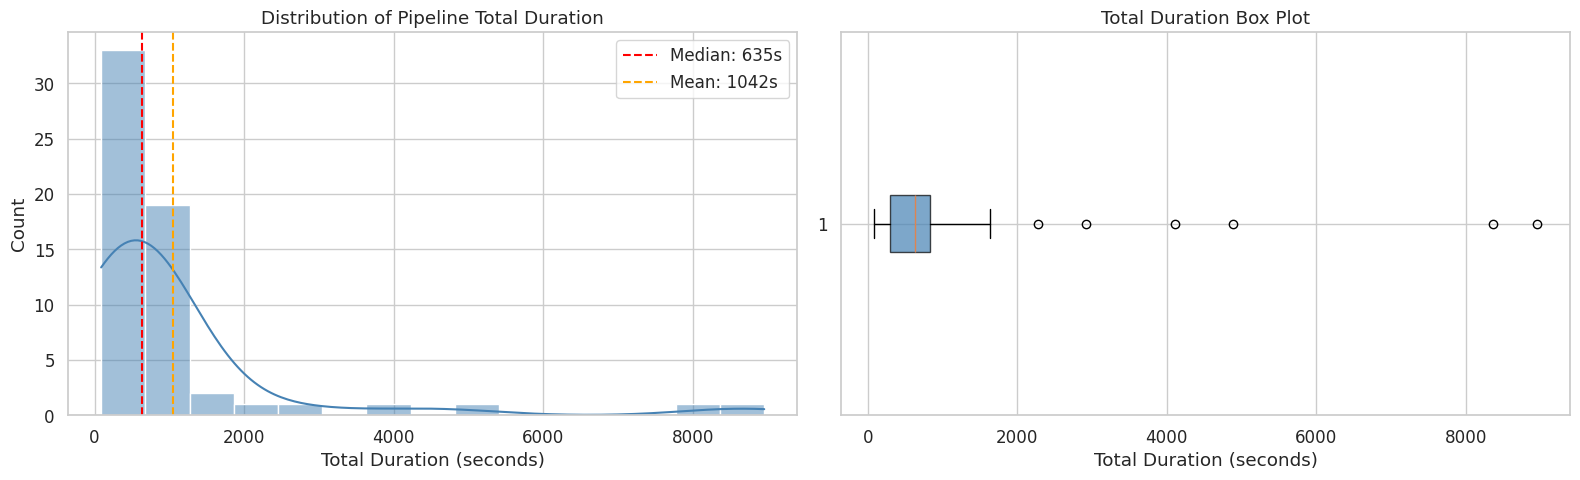

  Mean:   1041.6s (17.4 min)
  Median: 635.1s (10.6 min)
  Std:    1664.7s
  Min:    86.5s
  Max:    8953.4s (149.2 min)
  IQR:    538.3s
  Outliers (>1.5*IQR): 6 videos
    69d26461d1a79c20d403a99c: 4112s
    69d26461d1a79c20d403a99d: 8356s
    69d26461d1a79c20d403a99e: 8953s
    69d1fa20846a50051062bee0: 4882s
    69d3bac406491d0fe176745a: 2281s
    69d3cc4c06491d0fe1767462: 2918s


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid", font_scale=1.1)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

total_dur = df['timing_Total'].dropna()

# Histogram + KDE
sns.histplot(total_dur, kde=True, bins=15, color='steelblue', ax=axes[0])
axes[0].axvline(total_dur.median(), color='red', linestyle='--', label=f'Median: {total_dur.median():.0f}s')
axes[0].axvline(total_dur.mean(), color='orange', linestyle='--', label=f'Mean: {total_dur.mean():.0f}s')
axes[0].set_xlabel('Total Duration (seconds)')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Pipeline Total Duration')
axes[0].legend()

# Box plot
axes[1].boxplot(total_dur, vert=False, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.7))
axes[1].set_xlabel('Total Duration (seconds)')
axes[1].set_title('Total Duration Box Plot')

plt.tight_layout()
plt.show()

print(f"  Mean:   {total_dur.mean():.1f}s ({total_dur.mean()/60:.1f} min)")
print(f"  Median: {total_dur.median():.1f}s ({total_dur.median()/60:.1f} min)")
print(f"  Std:    {total_dur.std():.1f}s")
print(f"  Min:    {total_dur.min():.1f}s")
print(f"  Max:    {total_dur.max():.1f}s ({total_dur.max()/60:.1f} min)")
print(f"  IQR:    {total_dur.quantile(0.75) - total_dur.quantile(0.25):.1f}s")
outliers = total_dur[total_dur > total_dur.quantile(0.75) + 1.5*(total_dur.quantile(0.75) - total_dur.quantile(0.25))]
print(f"  Outliers (>1.5*IQR): {len(outliers)} videos")
for v in outliers.index:
    print(f"    {df.loc[v, 'video_id']}: {total_dur.loc[v]:.0f}s")

/tmp/ipykernel_1259733/2306858772.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=timing_melt, x='Duration (s)', y='Stage', ax=axes[0],


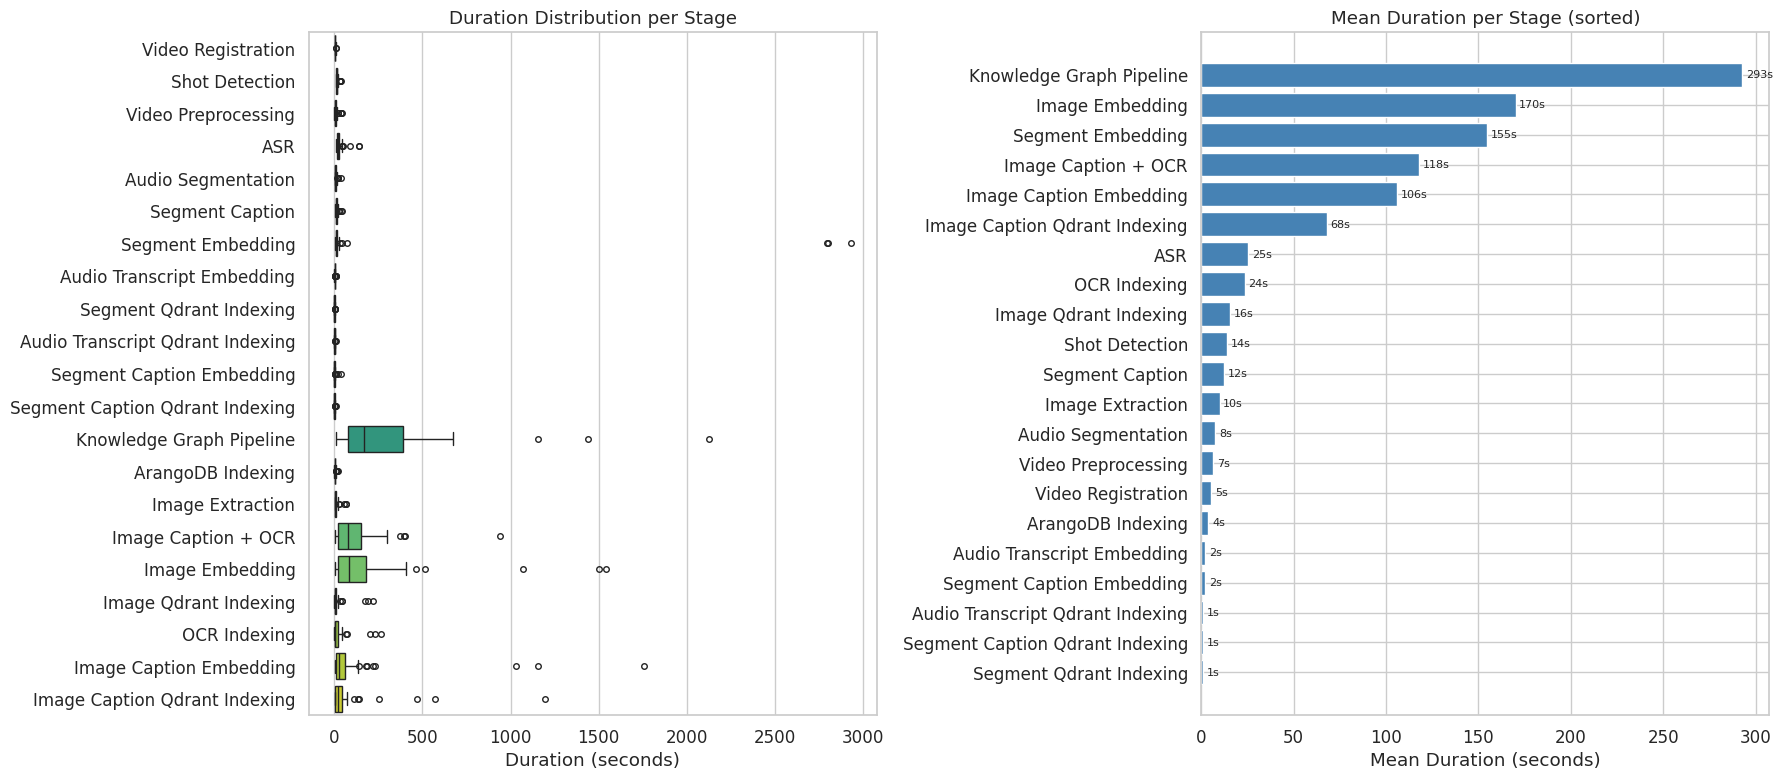

Top 5 stages by mean duration:
  Image Caption Embedding: 106.1s (10.2%)
  Image Caption + OCR: 117.9s (11.3%)
  Segment Embedding: 154.6s (14.8%)
  Image Embedding: 170.1s (16.3%)
  Knowledge Graph Pipeline: 292.8s (28.1%)


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

timing_cols = [c for c in df.columns if c.startswith('timing_') and c != 'timing_Total']
timing_df = df[timing_cols].copy()
timing_df.columns = [c.replace('timing_', '') for c in timing_cols]

# Box plot of all stages
timing_melt = timing_df.melt(var_name='Stage', value_name='Duration (s)')
sns.boxplot(data=timing_melt, x='Duration (s)', y='Stage', ax=axes[0],
            palette='viridis', fliersize=4)
axes[0].set_title('Duration Distribution per Stage')
axes[0].set_xlabel('Duration (seconds)')
axes[0].set_ylabel('')

# Mean duration bar chart (sorted)
means = timing_df.mean().sort_values(ascending=True)
axes[1].barh(means.index, means.values, color='steelblue')
axes[1].set_title('Mean Duration per Stage (sorted)')
axes[1].set_xlabel('Mean Duration (seconds)')
for i, (stage, val) in enumerate(means.items()):
    axes[1].text(val + 2, i, f'{val:.0f}s', va='center', fontsize=8)

plt.tight_layout()
plt.show()

print("Top 5 stages by mean duration:")
for stage, val in means.tail(5).items():
    pct = val / df['timing_Total'].mean() * 100
    print(f"  {stage}: {val:.1f}s ({pct:.1f}%)")

/tmp/ipykernel_1259733/4114443376.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=cost_melt, x='Cost ($)', y='Stage', ax=axes[1],


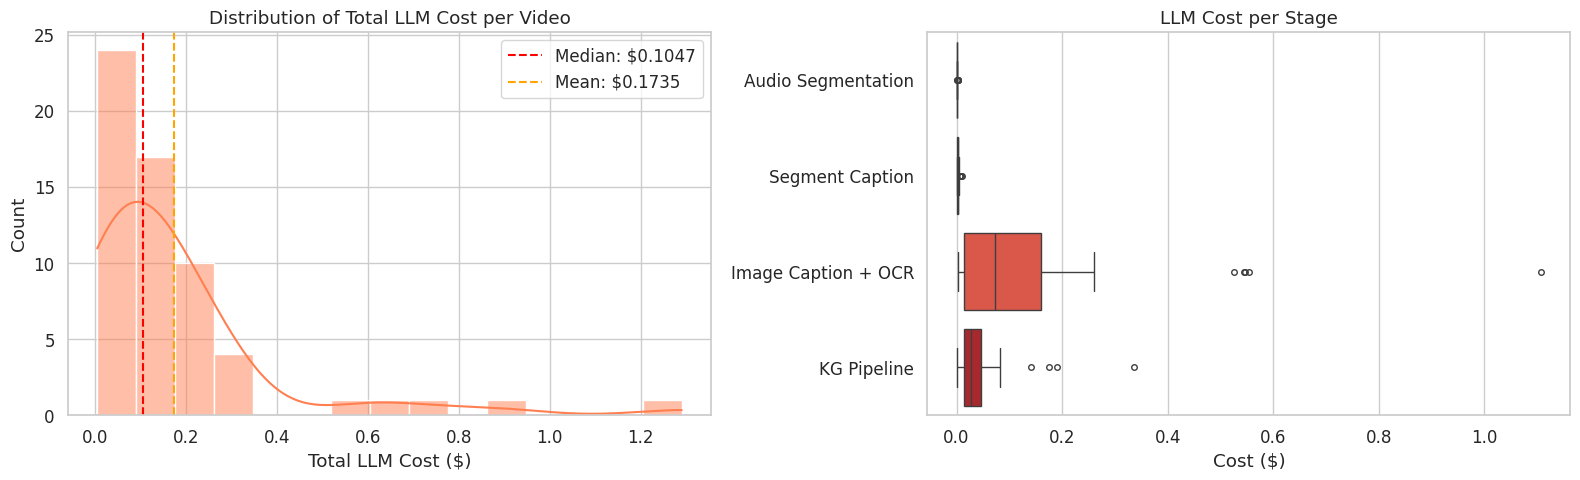

  Mean cost:   $0.1735
  Median cost: $0.1047
  Std cost:    $0.2275
  Min cost:    $0.0042
  Max cost:    $1.2904
  Total cost across 60 videos: $10.4094

Cost breakdown by stage (mean):
  Audio Segmentation: $0.0006 (0.4%)
  Segment Caption: $0.0023 (1.3%)
  Image Caption + OCR: $0.1293 (74.5%)
  KG Pipeline: $0.0413 (23.8%)


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

total_cost = df['cost_TOTAL'].dropna()

# Histogram
sns.histplot(total_cost, kde=True, bins=15, color='coral', ax=axes[0])
axes[0].axvline(total_cost.median(), color='red', linestyle='--', label=f'Median: ${total_cost.median():.4f}')
axes[0].axvline(total_cost.mean(), color='orange', linestyle='--', label=f'Mean: ${total_cost.mean():.4f}')
axes[0].set_xlabel('Total LLM Cost ($)')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Total LLM Cost per Video')
axes[0].legend()

# Cost per stage box plot
cost_cols = [c for c in df.columns if c.startswith('cost_') and c != 'cost_TOTAL']
cost_df = df[cost_cols].copy()
cost_df.columns = [c.replace('cost_', '') for c in cost_cols]
cost_melt = cost_df.melt(var_name='Stage', value_name='Cost ($)')
sns.boxplot(data=cost_melt, x='Cost ($)', y='Stage', ax=axes[1],
            palette='Reds', fliersize=4)
axes[1].set_title('LLM Cost per Stage')
axes[1].set_xlabel('Cost ($)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

print(f"  Mean cost:   ${total_cost.mean():.4f}")
print(f"  Median cost: ${total_cost.median():.4f}")
print(f"  Std cost:    ${total_cost.std():.4f}")
print(f"  Min cost:    ${total_cost.min():.4f}")
print(f"  Max cost:    ${total_cost.max():.4f}")
print(f"  Total cost across {len(total_cost)} videos: ${total_cost.sum():.4f}")

print("\nCost breakdown by stage (mean):")
for stage in cost_df.columns:
    mean_val = cost_df[stage].mean()
    pct = mean_val / total_cost.mean() * 100
    print(f"  {stage}: ${mean_val:.4f} ({pct:.1f}%)")

/tmp/ipykernel_1259733/90346191.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=art_melt, x='Count', y='Artifact Type', ax=axes[0],


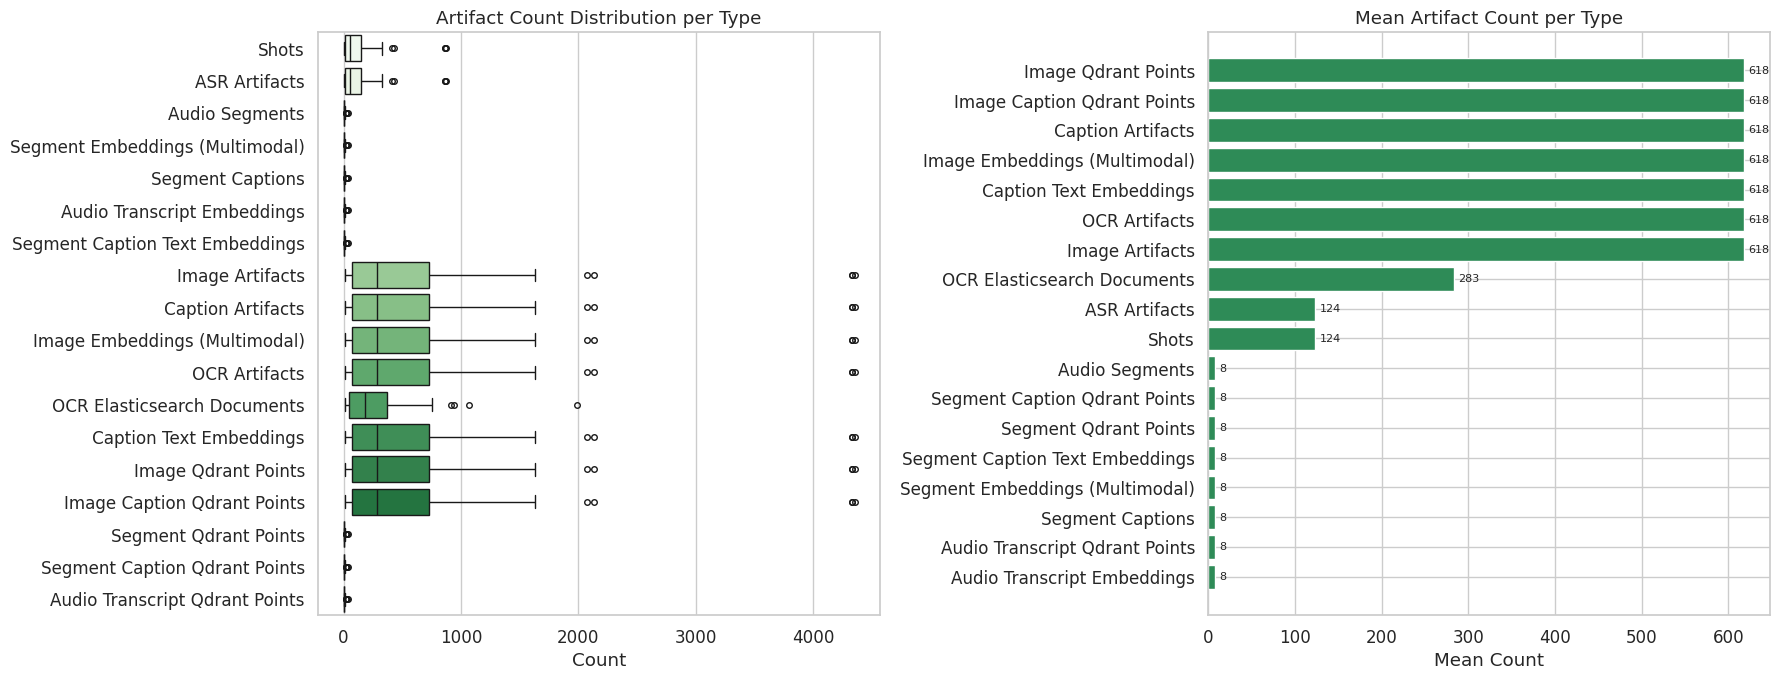

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

art_cols = [c for c in df.columns if c.startswith('artifacts_')]
art_df = df[art_cols].copy()
art_df.columns = [c.replace('artifacts_', '') for c in art_cols]

# Box plot of artifact counts
art_melt = art_df.melt(var_name='Artifact Type', value_name='Count')
sns.boxplot(data=art_melt, x='Count', y='Artifact Type', ax=axes[0],
            palette='Greens', fliersize=4)
axes[0].set_title('Artifact Count Distribution per Type')
axes[0].set_xlabel('Count')
axes[0].set_ylabel('')

# Mean artifact counts bar chart
means = art_df.mean().sort_values(ascending=True)
axes[1].barh(means.index, means.values, color='seagreen')
axes[1].set_title('Mean Artifact Count per Type')
axes[1].set_xlabel('Mean Count')
for i, (t, val) in enumerate(means.items()):
    axes[1].text(val + 5, i, f'{val:.0f}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

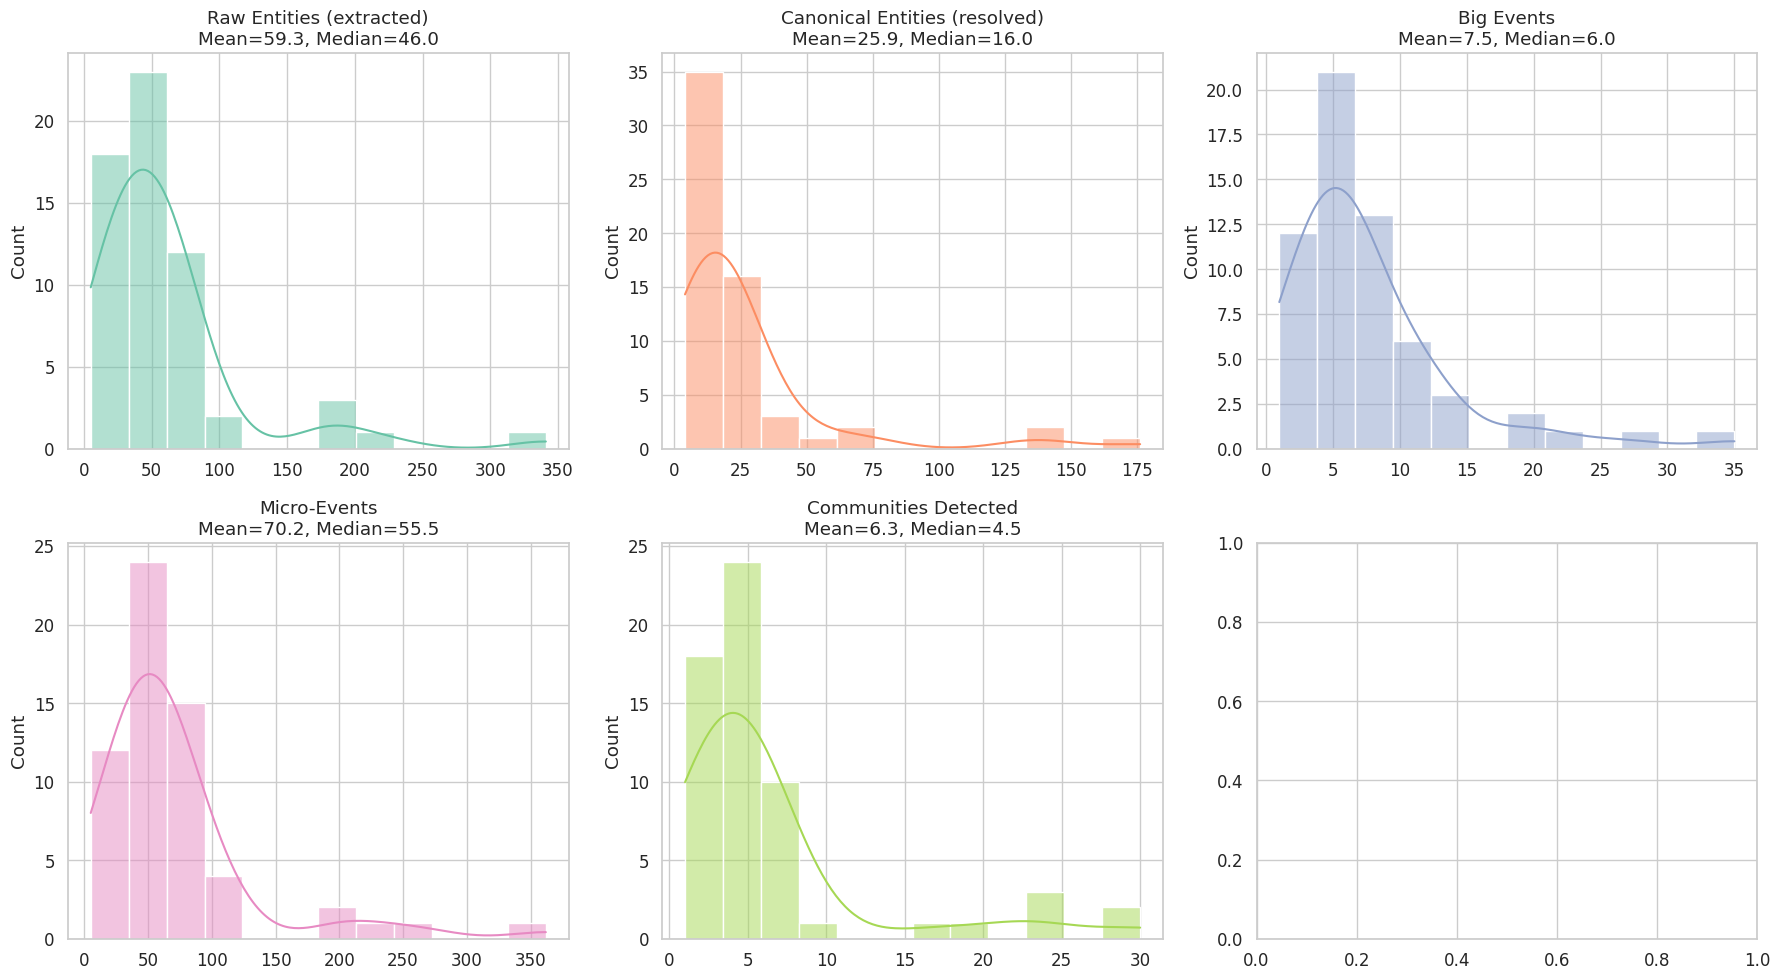

KG Statistics Summary:
  Raw Entities (extracted): mean=59.3, median=46.0, std=57.7, range=[5, 341]
  Canonical Entities (resolved): mean=25.9, median=16.0, std=32.4, range=[4, 176]
  Big Events: mean=7.5, median=6.0, std=6.3, range=[1, 35]
  Micro-Events: mean=70.2, median=55.5, std=63.8, range=[5, 362]
  Communities Detected: mean=6.3, median=4.5, std=6.7, range=[1, 30]


In [16]:
kg_cols = [c for c in df.columns if c.startswith('kg_')]
kg_df = df[kg_cols].copy()
kg_df.columns = [c.replace('kg_', '') for c in kg_cols]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

kg_metrics = ['Raw Entities (extracted)', 'Canonical Entities (resolved)',
              'Big Events', 'Micro-Events', 'Communities Detected']

colors = sns.color_palette('Set2', len(kg_metrics))

for i, metric in enumerate(kg_metrics):
    if metric in kg_df.columns:
        vals = kg_df[metric].dropna()
        sns.histplot(vals, kde=True, bins=12, color=colors[i], ax=axes[i])
        axes[i].set_title(f'{metric}\nMean={vals.mean():.1f}, Median={vals.median():.1f}')
        axes[i].set_xlabel('')

plt.tight_layout()
plt.show()

print("KG Statistics Summary:")
for metric in kg_metrics:
    if metric in kg_df.columns:
        vals = kg_df[metric].dropna()
        print(f"  {metric}: mean={vals.mean():.1f}, median={vals.median():.1f}, std={vals.std():.1f}, range=[{vals.min():.0f}, {vals.max():.0f}]")

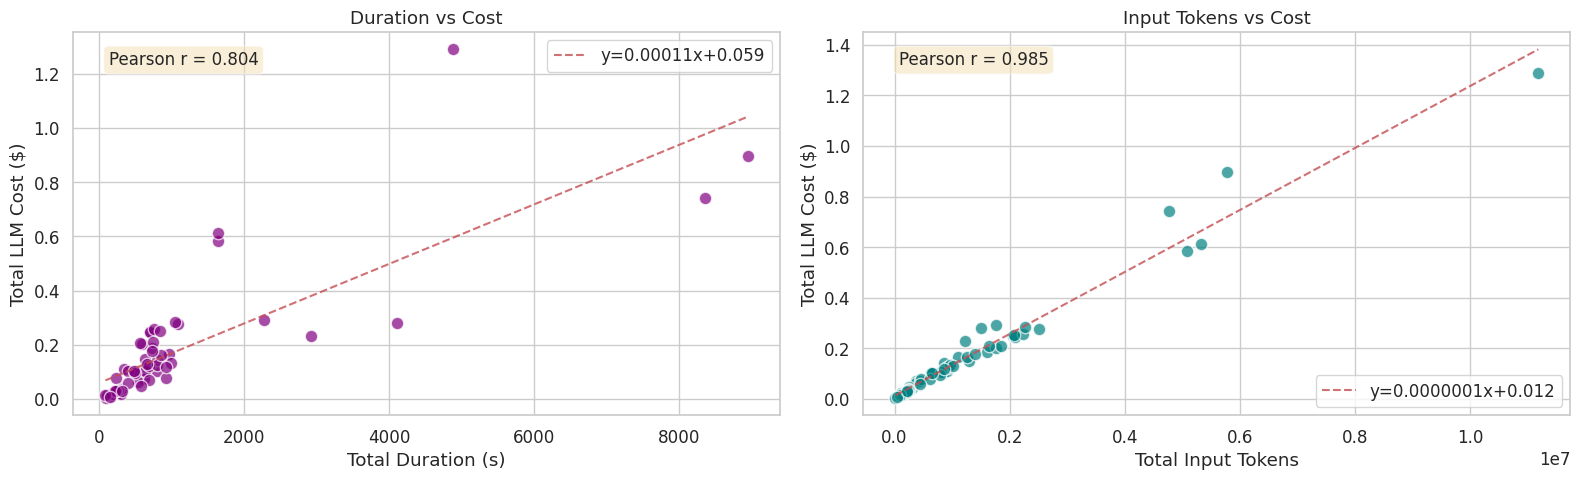

Duration vs Cost correlation: 0.804
Input Tokens vs Cost correlation: 0.985

Insight: Token count should be a stronger predictor of cost than duration.


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Scatter: duration vs cost
axes[0].scatter(df['timing_Total'], df['cost_TOTAL'], s=80, alpha=0.7, color='purple', edgecolors='white')
z = np.polyfit(df['timing_Total'].dropna(), df['cost_TOTAL'].dropna(), 1)
p = np.poly1d(z)
x_line = np.linspace(df['timing_Total'].min(), df['timing_Total'].max(), 100)
axes[0].plot(x_line, p(x_line), 'r--', alpha=0.8, label=f'y={z[0]:.5f}x+{z[1]:.3f}')
axes[0].set_xlabel('Total Duration (s)')
axes[0].set_ylabel('Total LLM Cost ($)')
axes[0].set_title('Duration vs Cost')
axes[0].legend()

corr = df['timing_Total'].corr(df['cost_TOTAL'])
axes[0].text(0.05, 0.95, f'Pearson r = {corr:.3f}', transform=axes[0].transAxes,
             fontsize=12, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Scatter: input tokens vs cost
axes[1].scatter(df['tokens_in_TOTAL'], df['cost_TOTAL'], s=80, alpha=0.7, color='teal', edgecolors='white')
z2 = np.polyfit(df['tokens_in_TOTAL'].dropna(), df['cost_TOTAL'].dropna(), 1)
p2 = np.poly1d(z2)
x2 = np.linspace(df['tokens_in_TOTAL'].min(), df['tokens_in_TOTAL'].max(), 100)
axes[1].plot(x2, p2(x2), 'r--', alpha=0.8, label=f'y={z2[0]:.7f}x+{z2[1]:.3f}')
axes[1].set_xlabel('Total Input Tokens')
axes[1].set_ylabel('Total LLM Cost ($)')
axes[1].set_title('Input Tokens vs Cost')
axes[1].legend()

corr2 = df['tokens_in_TOTAL'].corr(df['cost_TOTAL'])
axes[1].text(0.05, 0.95, f'Pearson r = {corr2:.3f}', transform=axes[1].transAxes,
             fontsize=12, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

print(f"Duration vs Cost correlation: {corr:.3f}")
print(f"Input Tokens vs Cost correlation: {corr2:.3f}")
print("\nInsight: Token count should be a stronger predictor of cost than duration.")

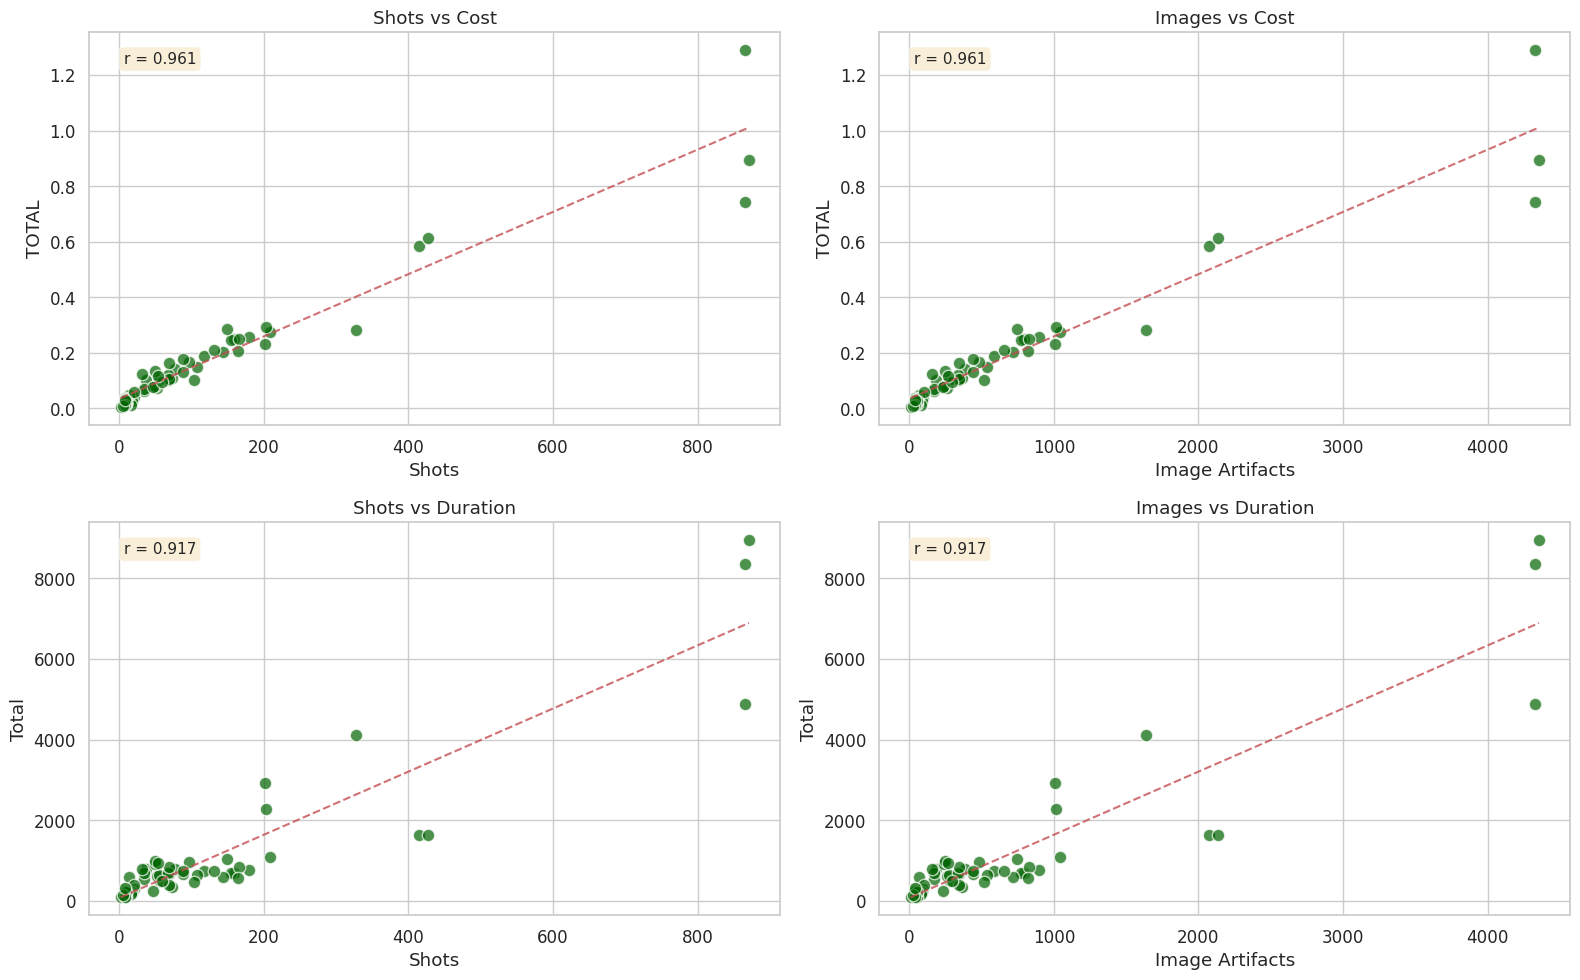

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

pairs = [
    ('artifacts_Shots', 'cost_TOTAL', 'Shots vs Cost'),
    ('artifacts_Image Artifacts', 'cost_TOTAL', 'Images vs Cost'),
    ('artifacts_Shots', 'timing_Total', 'Shots vs Duration'),
    ('artifacts_Image Artifacts', 'timing_Total', 'Images vs Duration'),
]

for i, (x_col, y_col, title) in enumerate(pairs):
    ax = axes[i // 2, i % 2]
    x = df[x_col].dropna()
    y = df[y_col].dropna()
    idx = x.index.intersection(y.index)
    ax.scatter(x.loc[idx], y.loc[idx], s=80, alpha=0.7, color='darkgreen', edgecolors='white')
    if len(idx) > 2:
        z = np.polyfit(x.loc[idx], y.loc[idx], 1)
        p = np.poly1d(z)
        x_line = np.linspace(x.loc[idx].min(), x.loc[idx].max(), 100)
        ax.plot(x_line, p(x_line), 'r--', alpha=0.8)
        r = x.loc[idx].corr(y.loc[idx])
        ax.text(0.05, 0.95, f'r = {r:.3f}', transform=ax.transAxes,
                fontsize=11, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    ax.set_xlabel(x_col.replace('artifacts_', ''))
    ax.set_ylabel(y_col.replace('timing_', '').replace('cost_', ''))
    ax.set_title(title)

plt.tight_layout()
plt.show()

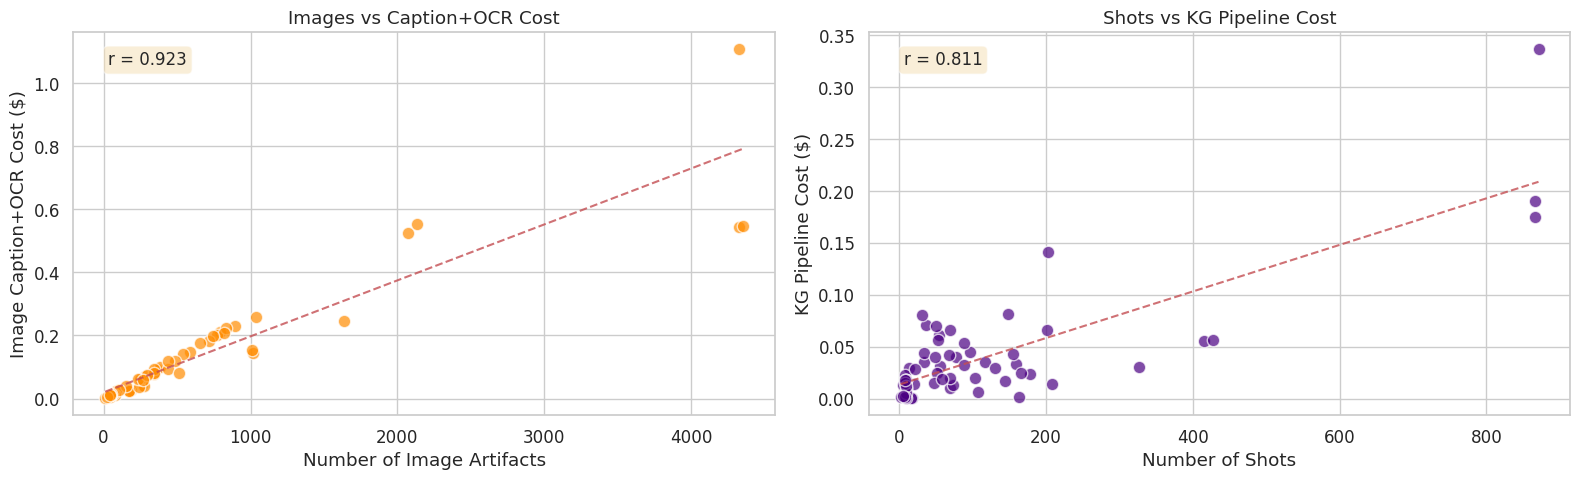

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Images vs Image Caption+OCR cost
x = df['artifacts_Image Artifacts']
y = df['cost_Image Caption + OCR']
idx = x.dropna().index.intersection(y.dropna().index)
axes[0].scatter(x.loc[idx], y.loc[idx], s=80, alpha=0.7, color='darkorange', edgecolors='white')
if len(idx) > 2:
    z = np.polyfit(x.loc[idx], y.loc[idx], 1)
    p = np.poly1d(z)
    x_line = np.linspace(x.loc[idx].min(), x.loc[idx].max(), 100)
    axes[0].plot(x_line, p(x_line), 'r--', alpha=0.8)
    r = x.loc[idx].corr(y.loc[idx])
    axes[0].text(0.05, 0.95, f'r = {r:.3f}', transform=axes[0].transAxes,
                 fontsize=12, verticalalignment='top',
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
axes[0].set_xlabel('Number of Image Artifacts')
axes[0].set_ylabel('Image Caption+OCR Cost ($)')
axes[0].set_title('Images vs Caption+OCR Cost')

# Shots vs KG cost
x2 = df['artifacts_Shots']
y2 = df['cost_KG Pipeline']
idx2 = x2.dropna().index.intersection(y2.dropna().index)
axes[1].scatter(x2.loc[idx2], y2.loc[idx2], s=80, alpha=0.7, color='indigo', edgecolors='white')
if len(idx2) > 2:
    z2 = np.polyfit(x2.loc[idx2], y2.loc[idx2], 1)
    p2 = np.poly1d(z2)
    x_line2 = np.linspace(x2.loc[idx2].min(), x2.loc[idx2].max(), 100)
    axes[1].plot(x_line2, p2(x_line2), 'r--', alpha=0.8)
    r2 = x2.loc[idx2].corr(y2.loc[idx2])
    axes[1].text(0.05, 0.95, f'r = {r2:.3f}', transform=axes[1].transAxes,
                 fontsize=12, verticalalignment='top',
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
axes[1].set_xlabel('Number of Shots')
axes[1].set_ylabel('KG Pipeline Cost ($)')
axes[1].set_title('Shots vs KG Pipeline Cost')

plt.tight_layout()
plt.show()

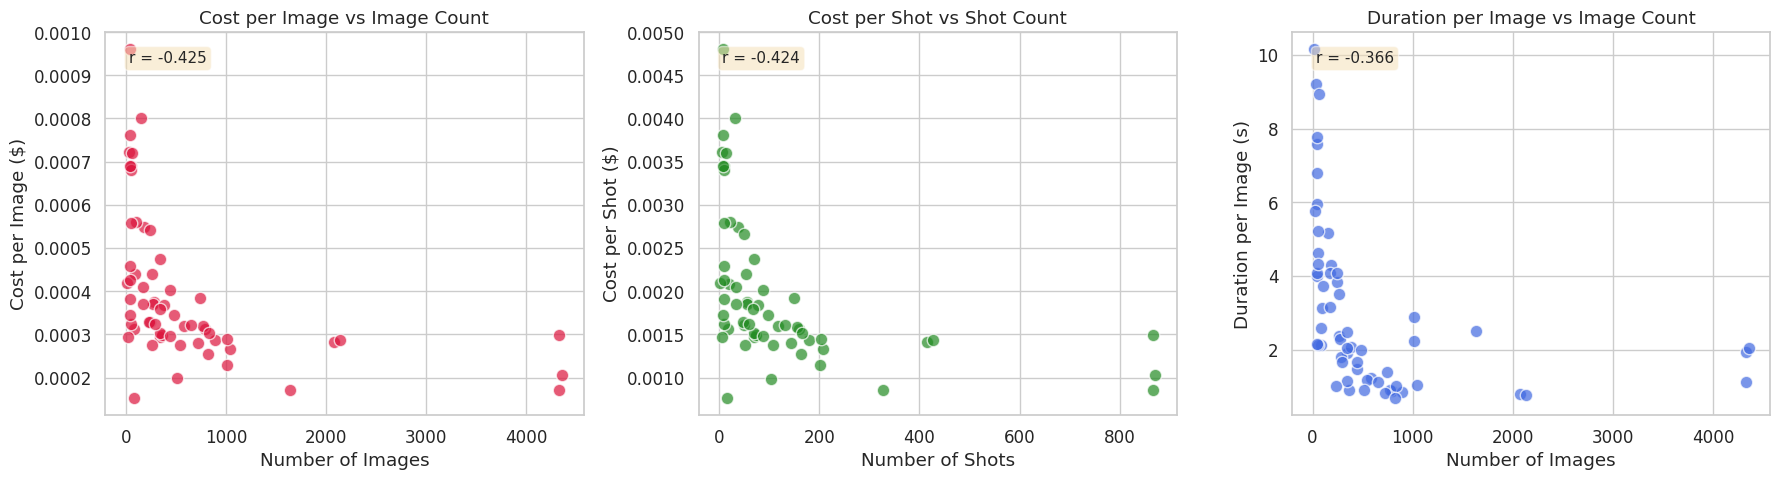

Efficiency metrics:
  Mean cost/image: $0.0004
  Mean cost/shot:  $0.0020
  Mean duration/image: 2.99s


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Cost per image vs image count
cost_per_img = df['cost_TOTAL'] / df['artifacts_Image Artifacts']
axes[0].scatter(df['artifacts_Image Artifacts'], cost_per_img, s=80, alpha=0.7, color='crimson', edgecolors='white')
axes[0].set_xlabel('Number of Images')
axes[0].set_ylabel('Cost per Image ($)')
axes[0].set_title('Cost per Image vs Image Count')
r = df['artifacts_Image Artifacts'].corr(cost_per_img)
axes[0].text(0.05, 0.95, f'r = {r:.3f}', transform=axes[0].transAxes,
             fontsize=11, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Cost per shot vs shot count
cost_per_shot = df['cost_TOTAL'] / df['artifacts_Shots']
axes[1].scatter(df['artifacts_Shots'], cost_per_shot, s=80, alpha=0.7, color='forestgreen', edgecolors='white')
axes[1].set_xlabel('Number of Shots')
axes[1].set_ylabel('Cost per Shot ($)')
axes[1].set_title('Cost per Shot vs Shot Count')
r = df['artifacts_Shots'].corr(cost_per_shot)
axes[1].text(0.05, 0.95, f'r = {r:.3f}', transform=axes[1].transAxes,
             fontsize=11, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Duration per image vs image count
dur_per_img = df['timing_Total'] / df['artifacts_Image Artifacts']
axes[2].scatter(df['artifacts_Image Artifacts'], dur_per_img, s=80, alpha=0.7, color='royalblue', edgecolors='white')
axes[2].set_xlabel('Number of Images')
axes[2].set_ylabel('Duration per Image (s)')
axes[2].set_title('Duration per Image vs Image Count')
r = df['artifacts_Image Artifacts'].corr(dur_per_img)
axes[2].text(0.05, 0.95, f'r = {r:.3f}', transform=axes[2].transAxes,
             fontsize=11, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

print("Efficiency metrics:")
print(f"  Mean cost/image: ${cost_per_img.mean():.4f}")
print(f"  Mean cost/shot:  ${cost_per_shot.mean():.4f}")
print(f"  Mean duration/image: {dur_per_img.mean():.2f}s")

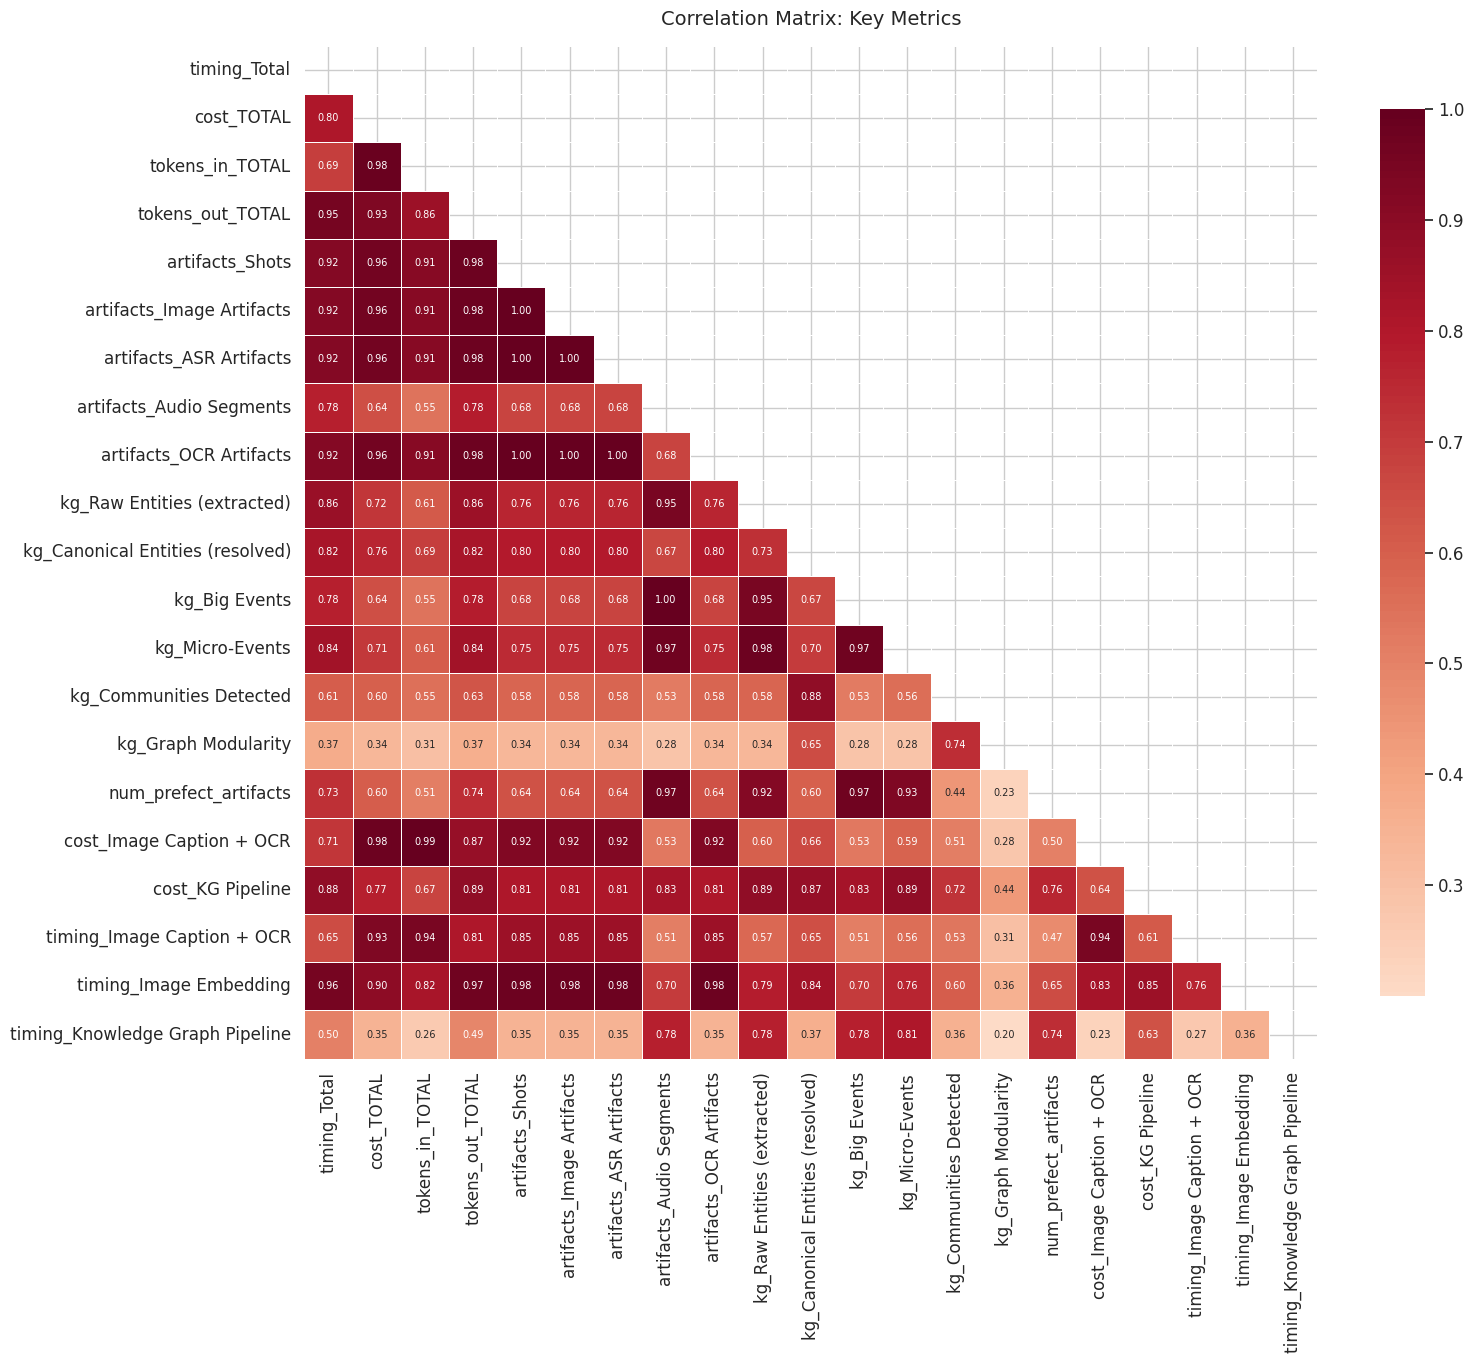

Top 10 correlations with Total Cost:
  + tokens_in_TOTAL: 0.985
  + cost_Image Caption + OCR: 0.982
  + artifacts_ASR Artifacts: 0.961
  + artifacts_Shots: 0.961
  + artifacts_OCR Artifacts: 0.961
  + artifacts_Image Artifacts: 0.961
  + tokens_out_TOTAL: 0.935
  + timing_Image Caption + OCR: 0.930
  + timing_Image Embedding: 0.897
  + timing_Total: 0.804


In [21]:
key_cols = [
    'timing_Total', 'cost_TOTAL', 'tokens_in_TOTAL', 'tokens_out_TOTAL',
    'artifacts_Shots', 'artifacts_Image Artifacts', 'artifacts_ASR Artifacts',
    'artifacts_Audio Segments', 'artifacts_OCR Artifacts',
    'kg_Raw Entities (extracted)', 'kg_Canonical Entities (resolved)',
    'kg_Big Events', 'kg_Micro-Events', 'kg_Communities Detected',
    'kg_Graph Modularity', 'num_prefect_artifacts',
    'cost_Image Caption + OCR', 'cost_KG Pipeline',
    'timing_Image Caption + OCR', 'timing_Image Embedding', 'timing_Knowledge Graph Pipeline',
]

key_cols = [c for c in key_cols if c in df.columns]
corr_matrix = df[key_cols].corr()

fig, ax = plt.subplots(figsize=(16, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8},
            annot_kws={'size': 7})
ax.set_title('Correlation Matrix: Key Metrics', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

# Top correlations with total cost
print("Top 10 correlations with Total Cost:")
cost_corr = corr_matrix['cost_TOTAL'].drop('cost_TOTAL').abs().sort_values(ascending=False)
for col, val in cost_corr.head(10).items():
    sign = '+' if corr_matrix.loc['cost_TOTAL', col] > 0 else '-'
    print(f"  {sign} {col}: {val:.3f}")

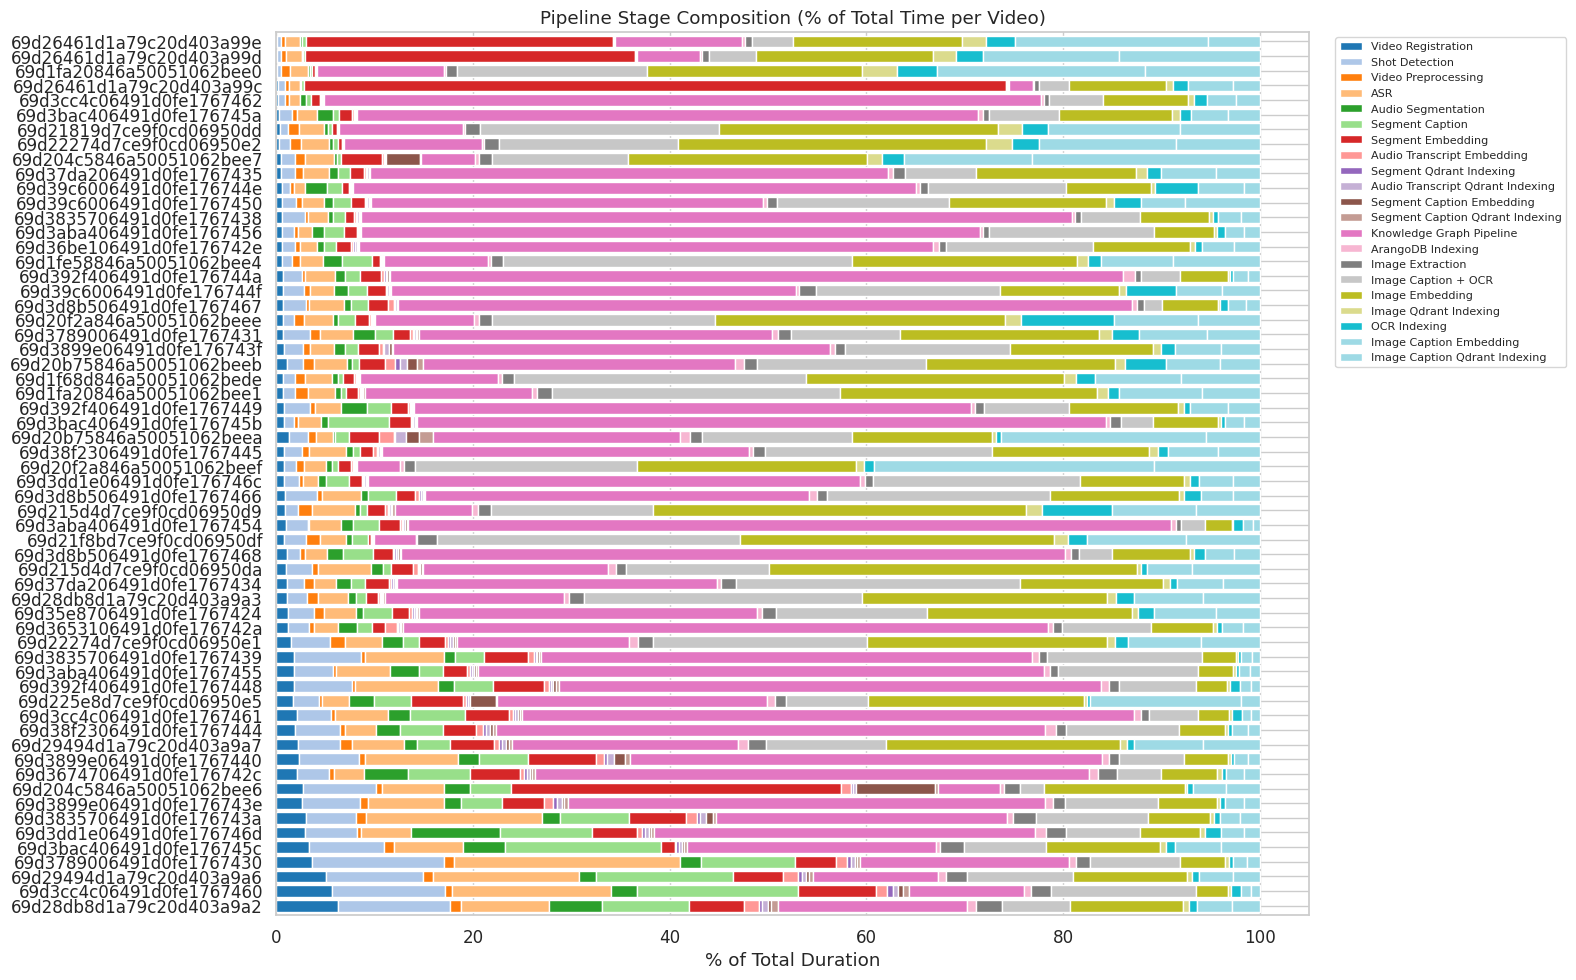

Average stage composition (% of total time):
  Segment Qdrant Indexing: 0.2%
  Segment Caption Qdrant Indexing: 0.2%
  Audio Transcript Qdrant Indexing: 0.2%
  Audio Transcript Embedding: 0.4%
  Segment Caption Embedding: 0.4%
  ArangoDB Indexing: 0.6%
  Video Preprocessing: 0.7%
  Image Qdrant Indexing: 0.8%
  Image Extraction: 1.2%
  Video Registration: 1.4%
  Audio Segmentation: 1.5%
  OCR Indexing: 1.6%
  Shot Detection: 3.1%
  Segment Caption: 3.1%
  Image Caption Qdrant Indexing: 4.3%
  ASR: 4.4%
  Segment Embedding: 5.2%
  Image Caption Embedding: 6.1%
  Image Caption + OCR: 13.6%
  Image Embedding: 14.5%
  Knowledge Graph Pipeline: 36.3%


In [22]:
timing_cols = [c for c in df.columns if c.startswith('timing_') and c != 'timing_Total']
timing_df = df[['video_id'] + timing_cols].copy()
timing_df.columns = ['video_id'] + [c.replace('timing_', '') for c in timing_cols]
timing_df = timing_df.set_index('video_id')

# Calculate percentage of total time
timing_pct = timing_df.div(df['timing_Total'].values, axis=0) * 100

# Sort by total duration
sorted_order = df.sort_values("timing_Total")["video_id"].tolist()
timing_pct = timing_pct.reindex(sorted_order)

fig, ax = plt.subplots(figsize=(16, 10))
timing_pct.plot(kind='barh', stacked=True, ax=ax, colormap='tab20', width=0.8)
ax.set_xlabel('% of Total Duration')
ax.set_ylabel('')
ax.set_title('Pipeline Stage Composition (% of Total Time per Video)')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

# Average composition
avg_pct = timing_pct.mean().sort_values(ascending=True)
print("Average stage composition (% of total time):")
for stage, pct in avg_pct.items():
    print(f"  {stage}: {pct:.1f}%")


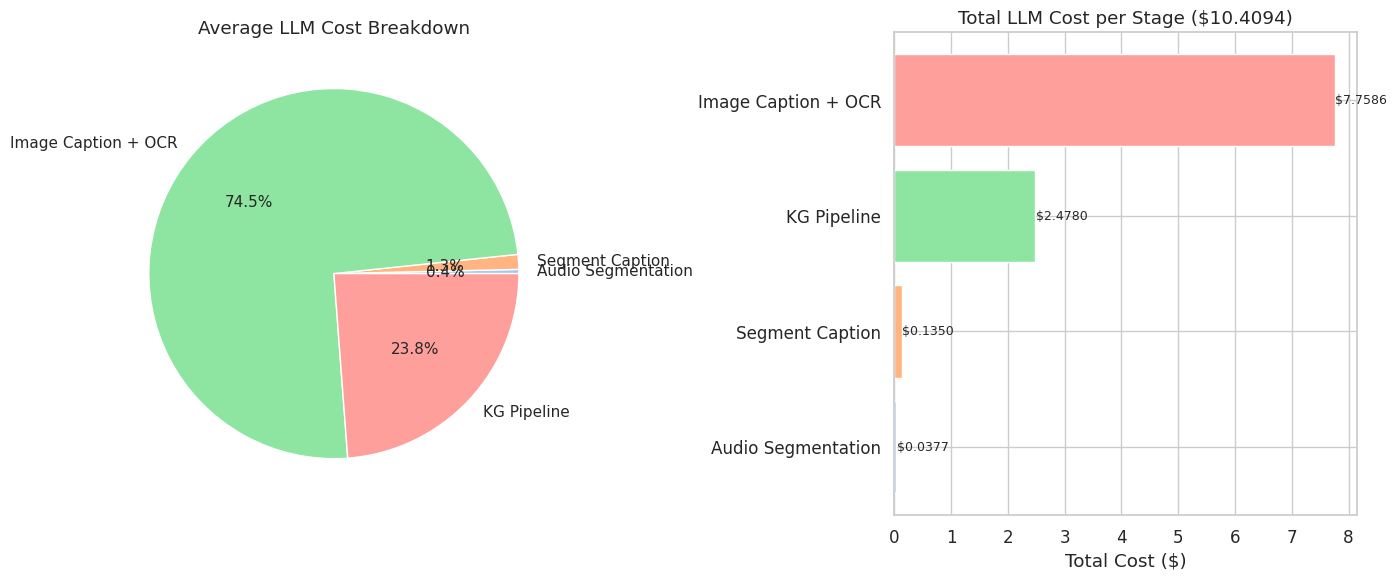

In [23]:
cost_cols = [c for c in df.columns if c.startswith('cost_') and c != 'cost_TOTAL']
cost_df = df[cost_cols].copy()
cost_df.columns = [c.replace('cost_', '') for c in cost_cols]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Pie chart of average cost breakdown
avg_cost = cost_df.mean()
axes[0].pie(avg_cost.values, labels=avg_cost.index, autopct='%1.1f%%',
            colors=sns.color_palette('pastel', len(avg_cost)),
            textprops={'fontsize': 11})
axes[0].set_title('Average LLM Cost Breakdown')

# Bar chart of total cost per stage
total_per_stage = cost_df.sum().sort_values(ascending=True)
axes[1].barh(total_per_stage.index, total_per_stage.values, color=sns.color_palette('pastel', len(total_per_stage)))
axes[1].set_xlabel('Total Cost ($)')
axes[1].set_title(f'Total LLM Cost per Stage (${total_per_stage.sum():.4f})')
for i, (stage, val) in enumerate(total_per_stage.items()):
    axes[1].text(val + 0.01, i, f'${val:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

In [24]:
outlier_metrics = ['timing_Total', 'cost_TOTAL', 'tokens_in_TOTAL',
                   'artifacts_Image Artifacts', 'artifacts_Shots',
                   'kg_Raw Entities (extracted)']
outlier_metrics = [c for c in outlier_metrics if c in df.columns]

outlier_results = []
for col in outlier_metrics:
    vals = df[col].dropna()
    mean, std = vals.mean(), vals.std()
    z_scores = (vals - mean) / std
    outliers = z_scores[abs(z_scores) > 2]
    for idx, z in outliers.items():
        outlier_results.append({
            'video_id': df.loc[idx, 'video_id'],
            'metric': col,
            'value': df.loc[idx, col],
            'z_score': z,
        })

df_outliers = pd.DataFrame(outlier_results)
if len(df_outliers) > 0:
    print(f"Found {len(df_outliers)} outlier observations (|z| > 2):")
    display(df_outliers.sort_values('z_score', ascending=False).head(15))
else:
    print("No outliers detected (|z| > 2).")

# Videos that appear as outliers most often
if len(df_outliers) > 0:
    print("\nVideos with most outlier metrics:")
    vid_counts = df_outliers['video_id'].value_counts()
    for vid, count in vid_counts.head(5).items():
        metrics = df_outliers[df_outliers['video_id'] == vid]['metric'].tolist()
        print(f"  {vid}: {count} outlier(s) - {', '.join(metrics)}")

Found 21 outlier observations (|z| > 2):


,video_id,metric,value,z_score
7,69d1fa20846a50051062bee0,tokens_in_TOTAL,1.117877e+07,5.394933
5,69d1fa20846a50051062bee0,cost_TOTAL,1.290449e+00,4.909613
17,69d26461d1a79c20d403a99e,kg_Raw Entities (extracted),3.410000e+02,4.884361
1,69d26461d1a79c20d403a99e,timing_Total,8.953380e+03,4.752550
0,69d26461d1a79c20d403a99d,timing_Total,8.356440e+03,4.393971
11,69d26461d1a79c20d403a99e,artifacts_Image Artifacts,4.355000e+03,3.831194
14,69d26461d1a79c20d403a99e,artifacts_Shots,8.710000e+02,3.831180
12,69d1fa20846a50051062bee0,artifacts_Image Artifacts,4.330000e+03,3.805567
10,69d26461d1a79c20d403a99d,artifacts_Image Artifacts,4.330000e+03,3.805567
13,69d26461d1a79c20d403a99d,artifacts_Shots,8.660000e+02,3.805551



Videos with most outlier metrics:
  69d26461d1a79c20d403a99e: 6 outlier(s) - timing_Total, cost_TOTAL, tokens_in_TOTAL, artifacts_Image Artifacts, artifacts_Shots, kg_Raw Entities (extracted)
  69d1fa20846a50051062bee0: 6 outlier(s) - timing_Total, cost_TOTAL, tokens_in_TOTAL, artifacts_Image Artifacts, artifacts_Shots, kg_Raw Entities (extracted)
  69d26461d1a79c20d403a99d: 5 outlier(s) - timing_Total, cost_TOTAL, artifacts_Image Artifacts, artifacts_Shots, kg_Raw Entities (extracted)
  69d21819d7ce9f0cd06950dd: 1 outlier(s) - tokens_in_TOTAL
  69d22274d7ce9f0cd06950e2: 1 outlier(s) - tokens_in_TOTAL


In [25]:
summary_metrics = {
    'Total Duration (s)': 'timing_Total',
    'Total Cost ($)': 'cost_TOTAL',
    'Total Input Tokens': 'tokens_in_TOTAL',
    'Total Output Tokens': 'tokens_out_TOTAL',
    'Total LLM Calls': 'llm_calls_TOTAL',
    'Shots': 'artifacts_Shots',
    'Image Artifacts': 'artifacts_Image Artifacts',
    'ASR Artifacts': 'artifacts_ASR Artifacts',
    'Audio Segments': 'artifacts_Audio Segments',
    'OCR Artifacts': 'artifacts_OCR Artifacts',
    'Raw Entities': 'kg_Raw Entities (extracted)',
    'Big Events': 'kg_Big Events',
    'Micro-Events': 'kg_Micro-Events',
    'Communities': 'kg_Communities Detected',
    'Graph Modularity': 'kg_Graph Modularity',
}

rows = []
for label, col in summary_metrics.items():
    if col in df.columns:
        vals = df[col].dropna()
        rows.append({
            'Metric': label,
            'Mean': vals.mean(),
            'Median': vals.median(),
            'Std': vals.std(),
            'Min': vals.min(),
            'Max': vals.max(),
            'Count': len(vals),
        })

df_stats = pd.DataFrame(rows)
print("=== Summary Statistics ===")
display(df_stats.round(2))

# Derived metrics
print("\n=== Derived Metrics ===")
cost_per_sec = df['cost_TOTAL'].mean() / df['timing_Total'].mean()
cost_per_shot = df['cost_TOTAL'].mean() / df['artifacts_Shots'].mean()
cost_per_image = df['cost_TOTAL'].mean() / df['artifacts_Image Artifacts'].mean()
print(f"  Cost per second: ${cost_per_sec:.4f}")
print(f"  Cost per shot:   ${cost_per_shot:.4f}")
print(f"  Cost per image:  ${cost_per_image:.4f}")

# Top 3 most expensive
print(f"\nTop 3 most expensive videos:")
top3_cost = df.nlargest(3, 'cost_TOTAL')
for _, row in top3_cost.iterrows():
    print(f"  {row['video_id']}: ${row['cost_TOTAL']:.4f} ({row['timing_Total']:.0f}s)")

# Top 3 longest
print(f"\nTop 3 longest videos:")
top3_dur = df.nlargest(3, 'timing_Total')
for _, row in top3_dur.iterrows():
    print(f"  {row['video_id']}: {row['timing_Total']:.0f}s (${row['cost_TOTAL']:.4f})")

=== Summary Statistics ===


,Metric,Mean,Median,Std,Min,Max,Count
0,Total Duration (s),1041.63,635.1,1664.74,86.55,8953.38,60
1,Total Cost ($),0.17,0.1,0.23,0.00,1.29,60
2,Total Input Tokens,1319021.18,858378.5,1827593.54,16448.00,11178766.00,60
3,Total Output Tokens,130894.25,86222.5,172020.11,6347.00,879786.00,60
4,Total LLM Calls,NaN,NaN,NaN,NaN,NaN,0
5,Shots,123.58,57.5,195.09,2.00,871.00,60
6,Image Artifacts,617.50,287.5,975.54,10.00,4355.00,60
7,ASR Artifacts,123.58,57.5,195.09,2.00,871.00,60
8,Audio Segments,7.53,6.0,6.30,1.00,35.00,60
9,OCR Artifacts,617.50,287.5,975.54,10.00,4355.00,60



=== Derived Metrics ===
  Cost per second: $0.0002
  Cost per shot:   $0.0014
  Cost per image:  $0.0003

Top 3 most expensive videos:
  69d1fa20846a50051062bee0: $1.2904 (4882s)
  69d26461d1a79c20d403a99e: $0.8954 (8953s)
  69d26461d1a79c20d403a99d: $0.7421 (8356s)

Top 3 longest videos:
  69d26461d1a79c20d403a99e: 8953s ($0.8954)
  69d26461d1a79c20d403a99d: 8356s ($0.7421)
  69d1fa20846a50051062bee0: 4882s ($1.2904)


In [26]:
import subprocess
import tempfile
import os
from minio import Minio
from minio.error import S3Error

# Connect to MinIO
minio_client = Minio(
    "localhost:9000",
    access_key="minioadmin",
    secret_key="minioadmin",
    secure=False,
)

BUCKET = "videos"

def get_video_duration_ffprobe(file_path: str) -> float | None:
    """Extract video duration in seconds using ffprobe."""
    try:
        result = subprocess.run(
            [
                "ffprobe", "-v", "error",
                "-show_entries", "format=duration",
                "-of", "default=noprint_wrappers=1:nokey=1",
                file_path,
            ],
            capture_output=True,
            text=True,
            timeout=30,
        )
        if result.returncode == 0 and result.stdout.strip():
            return float(result.stdout.strip())
    except Exception as e:
        print(f"  ffprobe error: {e}")
    return None

def find_video_object(video_id: str) -> str | None:
    """Find the object name for a video ID in the bucket."""
    try:
        objects = minio_client.list_objects(BUCKET, prefix=video_id, recursive=True)
        for obj in objects:
            if obj.object_name:
                return obj.object_name
    except S3Error as e:
        print(f"  Error listing objects for {video_id}: {e}")
    return None

print("Retrieving video durations from MinIO 'videos' bucket...")
print(f"Total videos to process: {len(total_video_haystack_ids)}\n")

video_durations = {}  # video_id -> actual duration in seconds
errors = []

for i, video_id in enumerate(total_video_haystack_ids):
    print(f"[{i+1}/{len(total_video_haystack_ids)}] Processing {video_id}...")
    
    object_name = find_video_object(video_id)
    if not object_name:
        errors.append((video_id, "Object not found in bucket"))
        print(f"  WARNING: No object found for {video_id}")
        continue
    
    print(f"  Found object: {object_name}")
    
    try:
        response = minio_client.get_object(BUCKET, object_name)
        video_data = response.read()
        response.close()
        response.release_conn()
        
        ext = os.path.splitext(object_name)[1] or ".mp4"
        with tempfile.NamedTemporaryFile(suffix=ext, delete=False) as tmp:
            tmp.write(video_data)
            tmp_path = tmp.name
        
        duration = get_video_duration_ffprobe(tmp_path)
        os.unlink(tmp_path)
        
        if duration is not None:
            video_durations[video_id] = duration
            print(f"  Duration: {duration:.2f}s ({duration/60:.2f} min)")
        else:
            errors.append((video_id, "Failed to extract duration"))
            print(f"  WARNING: Could not extract duration")
            
    except S3Error as e:
        errors.append((video_id, f"S3 error: {e}"))
        print(f"  ERROR: {e}")
    except Exception as e:
        errors.append((video_id, f"Unexpected error: {e}"))
        print(f"  ERROR: {e}")

print(f"\nSuccessfully retrieved durations for {len(video_durations)}/{len(total_video_haystack_ids)} videos")
if errors:
    print(f"Errors for {len(errors)} videos:")
    for vid, err in errors[:5]:
        print(f"  {vid}: {err}")
    if len(errors) > 5:
        print(f"  ... and {len(errors) - 5} more")

Retrieving video durations from MinIO 'videos' bucket...
Total videos to process: 61

[1/61] Processing 69d1f68d846a50051062bede...
  Found object: 69d1f68d846a50051062bede.mp4
  Duration: 490.22s (8.17 min)
[2/61] Processing 69d1fa20846a50051062bee1...
  Found object: 69d1fa20846a50051062bee1.mp4
  Duration: 459.52s (7.66 min)
[3/61] Processing 69d204c5846a50051062bee7...
  Found object: 69d204c5846a50051062bee7.mp4
  Duration: 683.43s (11.39 min)
[4/61] Processing 69d26461d1a79c20d403a99c...
  Found object: 69d26461d1a79c20d403a99c.mp4
  Duration: 1193.46s (19.89 min)
[5/61] Processing 69d26461d1a79c20d403a99d...
  Found object: 69d26461d1a79c20d403a99d.mp4
  Duration: 1315.25s (21.92 min)
[6/61] Processing 69d20b75846a50051062beea...
  Found object: 69d20b75846a50051062beea.mp4
  Duration: 363.42s (6.06 min)
[7/61] Processing 69d26461d1a79c20d403a99e...
  Found object: 69d26461d1a79c20d403a99e.mp4
  Duration: 1171.73s (19.53 min)
[8/61] Processing 69d20b75846a50051062beeb...
  Found

In [27]:
# Compare actual video duration with pipeline total duration
comparison_rows = []

for video_id, actual_dur in video_durations.items():
    pipeline_dur_row = df[df['video_id'] == video_id]
    if len(pipeline_dur_row) > 0:
        pipeline_dur = pipeline_dur_row['timing_Total'].values[0]
        ratio = pipeline_dur / actual_dur if actual_dur > 0 else float('inf')
        diff = pipeline_dur - actual_dur
        
        comparison_rows.append({
            'video_id': video_id,
            'actual_duration_s': round(actual_dur, 2),
            'pipeline_duration_s': round(pipeline_dur, 2),
            'difference_s': round(diff, 2),
            'ratio_pipeline_to_actual': round(ratio, 2),
        })

df_comparison = pd.DataFrame(comparison_rows)

print("=== Video Duration vs Pipeline Duration Comparison ===")
print(f"Videos with both durations: {len(df_comparison)}\n")

display(df_comparison.head(10))

print(f"\n=== Summary Statistics ===")
print(f"Actual video duration:")
print(f"  Mean: {df_comparison['actual_duration_s'].mean():.2f}s ({df_comparison['actual_duration_s'].mean()/60:.2f} min)")
print(f"  Median: {df_comparison['actual_duration_s'].median():.2f}s")
print(f"  Min: {df_comparison['actual_duration_s'].min():.2f}s")
print(f"  Max: {df_comparison['actual_duration_s'].max():.2f}s")

print(f"\nPipeline total duration:")
print(f"  Mean: {df_comparison['pipeline_duration_s'].mean():.2f}s ({df_comparison['pipeline_duration_s'].mean()/60:.2f} min)")
print(f"  Median: {df_comparison['pipeline_duration_s'].median():.2f}s")
print(f"  Min: {df_comparison['pipeline_duration_s'].min():.2f}s")
print(f"  Max: {df_comparison['pipeline_duration_s'].max():.2f}s")

print(f"\nRatio (Pipeline / Actual):")
print(f"  Mean: {df_comparison['ratio_pipeline_to_actual'].mean():.2f}x")
print(f"  Median: {df_comparison['ratio_pipeline_to_actual'].median():.2f}x")
print(f"  Min: {df_comparison['ratio_pipeline_to_actual'].min():.2f}x")
print(f"  Max: {df_comparison['ratio_pipeline_to_actual'].max():.2f}x")

print(f"\nDifference (Pipeline - Actual):")
print(f"  Mean: {df_comparison['difference_s'].mean():.2f}s")
print(f"  Median: {df_comparison['difference_s'].median():.2f}s")

=== Video Duration vs Pipeline Duration Comparison ===
Videos with both durations: 60



,video_id,actual_duration_s,pipeline_duration_s,difference_s,ratio_pipeline_to_actual
0,69d1f68d846a50051062bede,490.22,699.91,209.69,1.43
1,69d1fa20846a50051062bee1,459.52,697.04,237.52,1.52
2,69d204c5846a50051062bee7,683.43,1085.30,401.87,1.59
3,69d26461d1a79c20d403a99c,1193.46,4112.31,2918.85,3.45
4,69d26461d1a79c20d403a99d,1315.25,8356.44,7041.19,6.35
5,69d20b75846a50051062beea,363.42,656.21,292.79,1.81
6,69d26461d1a79c20d403a99e,1171.73,8953.38,7781.65,7.64
7,69d20b75846a50051062beeb,374.98,728.91,353.93,1.94
8,69d20f2a846a50051062beee,413.34,758.09,344.75,1.83
9,69d20f2a846a50051062beef,351.20,638.21,287.01,1.82



=== Summary Statistics ===
Actual video duration:
  Mean: 604.74s (10.08 min)
  Median: 509.00s
  Min: 255.61s
  Max: 1954.80s

Pipeline total duration:
  Mean: 1041.63s (17.36 min)
  Median: 635.10s
  Min: 86.55s
  Max: 8953.38s

Ratio (Pipeline / Actual):
  Mean: 1.48x
  Median: 1.23x
  Min: 0.18x
  Max: 7.64x

Difference (Pipeline - Actual):
  Mean: 436.88s
  Median: 144.12s


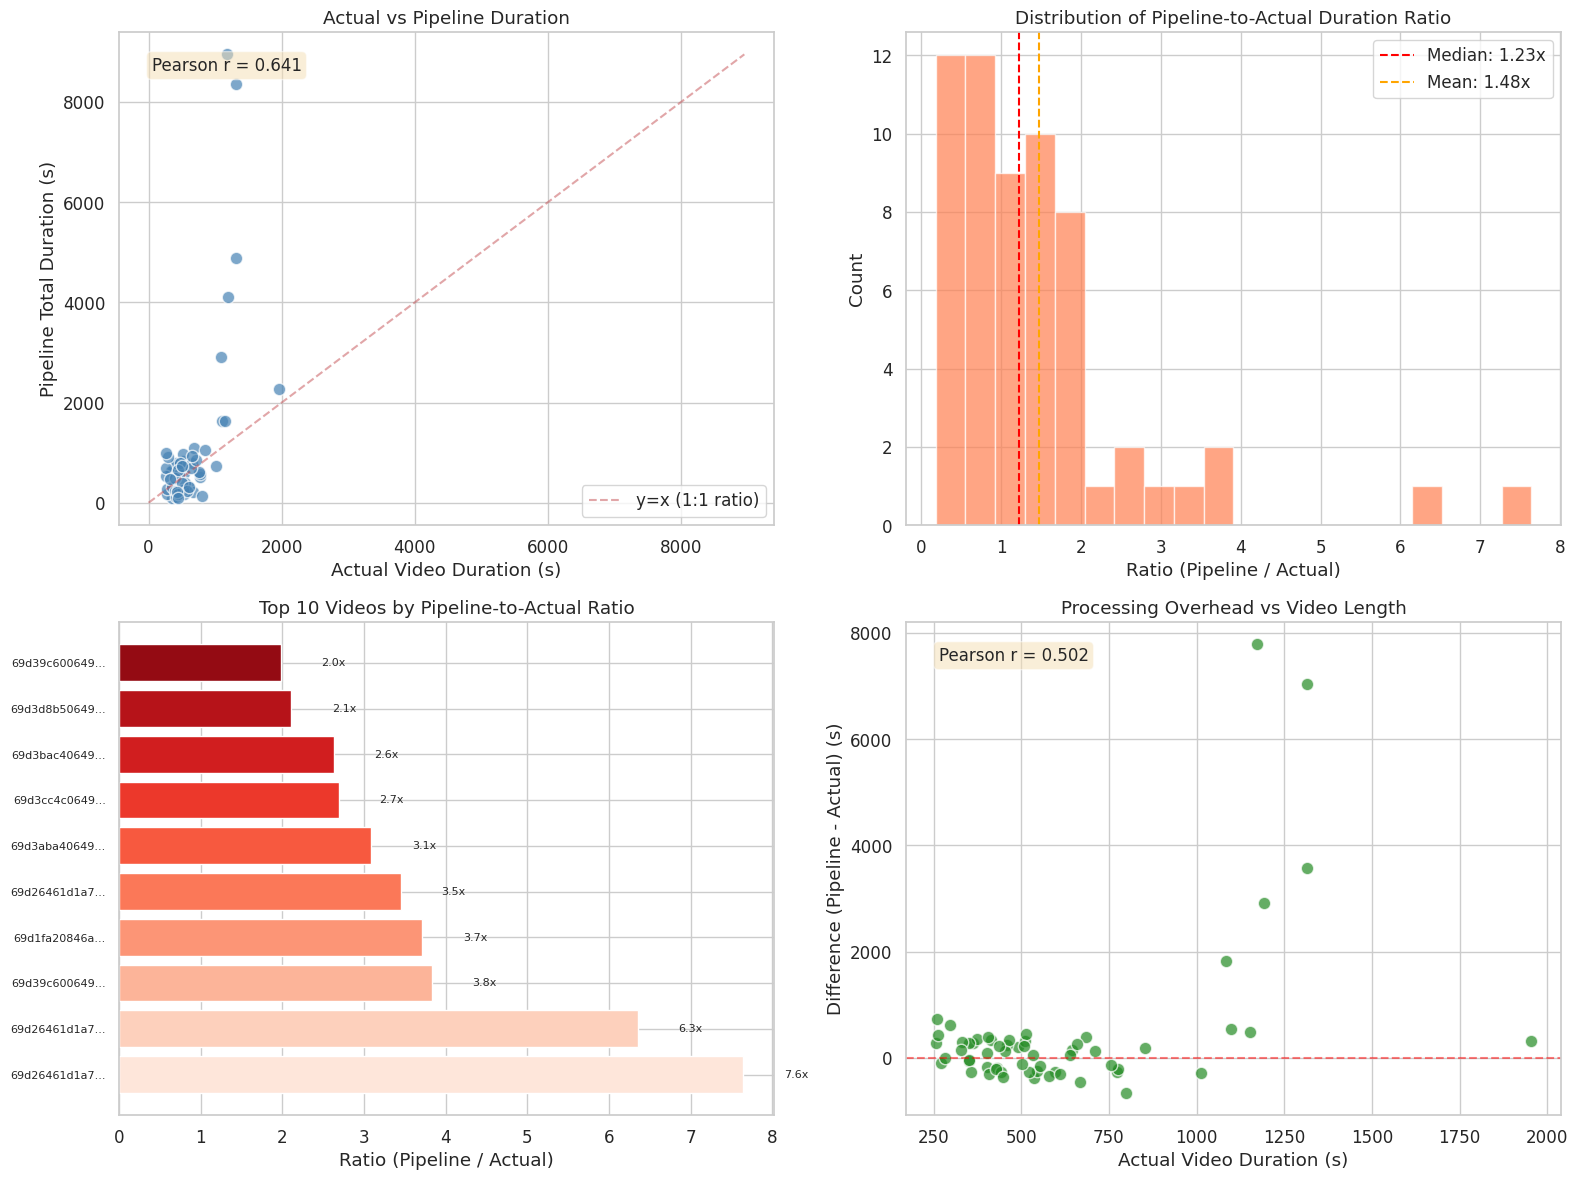


=== Key Insights ===
On average, the pipeline takes 1.5x the actual video duration
Median overhead: 144s (2.4 min)

Strong correlation (0.502) between video length and processing overhead
  -> Longer videos have proportionally more processing overhead


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.1)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Scatter: Actual vs Pipeline duration
axes[0, 0].scatter(df_comparison['actual_duration_s'], df_comparison['pipeline_duration_s'], 
                   s=80, alpha=0.7, color='steelblue', edgecolors='white')

max_dur = max(df_comparison['actual_duration_s'].max(), df_comparison['pipeline_duration_s'].max())
axes[0, 0].plot([0, max_dur], [0, max_dur], 'r--', alpha=0.5, label='y=x (1:1 ratio)')
axes[0, 0].set_xlabel('Actual Video Duration (s)')
axes[0, 0].set_ylabel('Pipeline Total Duration (s)')
axes[0, 0].set_title('Actual vs Pipeline Duration')
axes[0, 0].legend()

corr = df_comparison['actual_duration_s'].corr(df_comparison['pipeline_duration_s'])
axes[0, 0].text(0.05, 0.95, f'Pearson r = {corr:.3f}', transform=axes[0, 0].transAxes,
                fontsize=12, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# 2. Histogram of ratios
axes[0, 1].hist(df_comparison['ratio_pipeline_to_actual'], bins=20, color='coral', edgecolor='white', alpha=0.7)
axes[0, 1].axvline(df_comparison['ratio_pipeline_to_actual'].median(), color='red', linestyle='--', 
                   label=f'Median: {df_comparison["ratio_pipeline_to_actual"].median():.2f}x')
axes[0, 1].axvline(df_comparison['ratio_pipeline_to_actual'].mean(), color='orange', linestyle='--', 
                   label=f'Mean: {df_comparison["ratio_pipeline_to_actual"].mean():.2f}x')
axes[0, 1].set_xlabel('Ratio (Pipeline / Actual)')
axes[0, 1].set_ylabel('Count')
axes[0, 1].set_title('Distribution of Pipeline-to-Actual Duration Ratio')
axes[0, 1].legend()

# 3. Bar chart: Top 10 videos by ratio
top10_ratio = df_comparison.nlargest(10, 'ratio_pipeline_to_actual')
colors = sns.color_palette('Reds', len(top10_ratio))
axes[1, 0].barh(range(len(top10_ratio)), top10_ratio['ratio_pipeline_to_actual'], color=colors)
axes[1, 0].set_yticks(range(len(top10_ratio)))
axes[1, 0].set_yticklabels([vid[:12] + '...' for vid in top10_ratio['video_id']], fontsize=8)
axes[1, 0].set_xlabel('Ratio (Pipeline / Actual)')
axes[1, 0].set_title('Top 10 Videos by Pipeline-to-Actual Ratio')
for i, (idx, row) in enumerate(top10_ratio.iterrows()):
    axes[1, 0].text(row['ratio_pipeline_to_actual'] + 0.5, i, f"{row['ratio_pipeline_to_actual']:.1f}x", 
                    va='center', fontsize=8)

# 4. Scatter: Actual duration vs difference
axes[1, 1].scatter(df_comparison['actual_duration_s'], df_comparison['difference_s'], 
                   s=80, alpha=0.7, color='forestgreen', edgecolors='white')
axes[1, 1].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[1, 1].set_xlabel('Actual Video Duration (s)')
axes[1, 1].set_ylabel('Difference (Pipeline - Actual) (s)')
axes[1, 1].set_title('Processing Overhead vs Video Length')

diff_corr = df_comparison['actual_duration_s'].corr(df_comparison['difference_s'])
axes[1, 1].text(0.05, 0.95, f'Pearson r = {diff_corr:.3f}', transform=axes[1, 1].transAxes,
                fontsize=12, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

print("\n=== Key Insights ===")
print(f"On average, the pipeline takes {df_comparison['ratio_pipeline_to_actual'].mean():.1f}x the actual video duration")
print(f"Median overhead: {df_comparison['difference_s'].median():.0f}s ({df_comparison['difference_s'].median()/60:.1f} min)")

# Correlation between video length and processing overhead
if abs(diff_corr) > 0.5:
    print(f"\nStrong correlation ({diff_corr:.3f}) between video length and processing overhead")
    if diff_corr > 0:
        print("  -> Longer videos have proportionally more processing overhead")
    else:
        print("  -> Shorter videos have proportionally more processing overhead")
else:
    print(f"\nWeak correlation ({diff_corr:.3f}) between video length and processing overhead")
    print("  -> Processing time is relatively independent of video length")

In [32]:
top10_ratio

,video_id,actual_duration_s,pipeline_duration_s,difference_s,ratio_pipeline_to_actual
6,69d26461d1a79c20d403a99e,1171.73,8953.38,7781.65,7.64
4,69d26461d1a79c20d403a99d,1315.25,8356.44,7041.19,6.35
39,69d39c6006491d0fe176744e,260.34,996.89,736.55,3.83
12,69d1fa20846a50051062bee0,1315.25,4882.17,3566.92,3.71
3,69d26461d1a79c20d403a99c,1193.46,4112.31,2918.85,3.45
32,69d3aba406491d0fe1767456,298.00,922.20,624.20,3.09
22,69d3cc4c06491d0fe1767462,1082.89,2917.82,1834.93,2.69
31,69d3bac406491d0fe176745b,263.41,694.07,430.66,2.63
27,69d3d8b506491d0fe1767468,255.61,538.89,283.28,2.11
29,69d39c6006491d0fe176744f,404.26,798.88,394.62,1.98


In [29]:
# Merge video length, cost, and pipeline duration into one analysis
df_full = df_comparison.merge(df[['video_id', 'cost_TOTAL', 'tokens_in_TOTAL', 'artifacts_Shots', 'artifacts_Image Artifacts']], on='video_id', how='inner')
df_full['cost_per_min_video'] = df_full['cost_TOTAL'] / (df_full['actual_duration_s'] / 60)
df_full['pipeline_per_min_video'] = df_full['pipeline_duration_s'] / (df_full['actual_duration_s'] / 60)
df_full['cost_per_sec_video'] = df_full['cost_TOTAL'] / df_full['actual_duration_s']

print("=== Video Length vs Cost vs Pipeline Duration ===")
print(f"Videos analyzed: {len(df_full)}\n")

display(df_full[['video_id', 'actual_duration_s', 'pipeline_duration_s', 'cost_TOTAL', 'ratio_pipeline_to_actual', 'cost_per_min_video']].head(10))

print(f"\n=== Correlations ===")
corr_cols = ['actual_duration_s', 'pipeline_duration_s', 'cost_TOTAL', 'tokens_in_TOTAL', 'artifacts_Shots', 'artifacts_Image Artifacts']
corr_matrix = df_full[corr_cols].corr()
display(corr_matrix.round(3))

print(f"\n=== Key Metrics ===")
print(f"Mean cost per minute of video: ${df_full['cost_per_min_video'].mean():.4f}")
print(f"Median cost per minute of video: ${df_full['cost_per_min_video'].median():.4f}")
print(f"Mean pipeline seconds per minute of video: {df_full['pipeline_per_min_video'].mean():.1f}s")
print(f"Median pipeline seconds per minute of video: {df_full['pipeline_per_min_video'].median():.1f}s")

# Bucket videos by length
def duration_bucket(s):
    if s < 300:
        return '<5 min'
    elif s < 600:
        return '5-10 min'
    elif s < 900:
        return '10-15 min'
    elif s < 1200:
        return '15-20 min'
    else:
        return '20+ min'

df_full['duration_bucket'] = df_full['actual_duration_s'].apply(duration_bucket)
bucket_order = ['<5 min', '5-10 min', '10-15 min', '15-20 min', '20+ min']

print(f"\n=== By Video Length Bucket ===")
bucket_stats = df_full.groupby('duration_bucket').agg(
    count=('video_id', 'count'),
    avg_video_min=('actual_duration_s', lambda x: x.mean() / 60),
    avg_pipeline_s=('pipeline_duration_s', 'mean'),
    avg_cost=('cost_TOTAL', 'mean'),
    avg_ratio=('ratio_pipeline_to_actual', 'mean'),
    avg_cost_per_min=('cost_per_min_video', 'mean'),
).reindex(bucket_order)

display(bucket_stats.round(2))

=== Video Length vs Cost vs Pipeline Duration ===
Videos analyzed: 60



,video_id,actual_duration_s,pipeline_duration_s,cost_TOTAL,ratio_pipeline_to_actual,cost_per_min_video
0,69d1f68d846a50051062bede,490.22,699.91,0.248287,1.43,0.030389
1,69d1fa20846a50051062bee1,459.52,697.04,0.246675,1.52,0.032209
2,69d204c5846a50051062bee7,683.43,1085.30,0.276577,1.59,0.024281
3,69d26461d1a79c20d403a99c,1193.46,4112.31,0.280491,3.45,0.014101
4,69d26461d1a79c20d403a99d,1315.25,8356.44,0.742142,6.35,0.033856
5,69d20b75846a50051062beea,363.42,656.21,0.101633,1.81,0.016779
6,69d26461d1a79c20d403a99e,1171.73,8953.38,0.895393,7.64,0.045850
7,69d20b75846a50051062beeb,374.98,728.91,0.187268,1.94,0.029964
8,69d20f2a846a50051062beee,413.34,758.09,0.257507,1.83,0.037379
9,69d20f2a846a50051062beef,351.20,638.21,0.148621,1.82,0.025391



=== Correlations ===


,actual_duration_s,pipeline_duration_s,cost_TOTAL,tokens_in_TOTAL,artifacts_Shots,artifacts_Image Artifacts
actual_duration_s,1.000,0.641,0.658,0.604,0.670,0.670
pipeline_duration_s,0.641,1.000,0.804,0.693,0.917,0.917
cost_TOTAL,0.658,0.804,1.000,0.985,0.961,0.961
tokens_in_TOTAL,0.604,0.693,0.985,1.000,0.908,0.908
artifacts_Shots,0.670,0.917,0.961,0.908,1.000,1.000
artifacts_Image Artifacts,0.670,0.917,0.961,0.908,1.000,1.000



=== Key Metrics ===
Mean cost per minute of video: $0.0153
Median cost per minute of video: $0.0133
Mean pipeline seconds per minute of video: 88.8s
Median pipeline seconds per minute of video: 73.5s

=== By Video Length Bucket ===


,count,avg_video_min,avg_pipeline_s,avg_cost,avg_ratio,avg_cost_per_min
duration_bucket,,,,,,
<5 min,6,4.53,601.32,0.06,2.22,0.01
5-10 min,33,7.47,473.03,0.10,1.08,0.01
10-15 min,12,11.89,647.36,0.13,0.92,0.01
15-20 min,6,18.64,3331.95,0.47,2.90,0.02
20+ min,3,25.47,5173.19,0.78,3.74,0.03


/tmp/ipykernel_1259733/1052120268.py:92: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


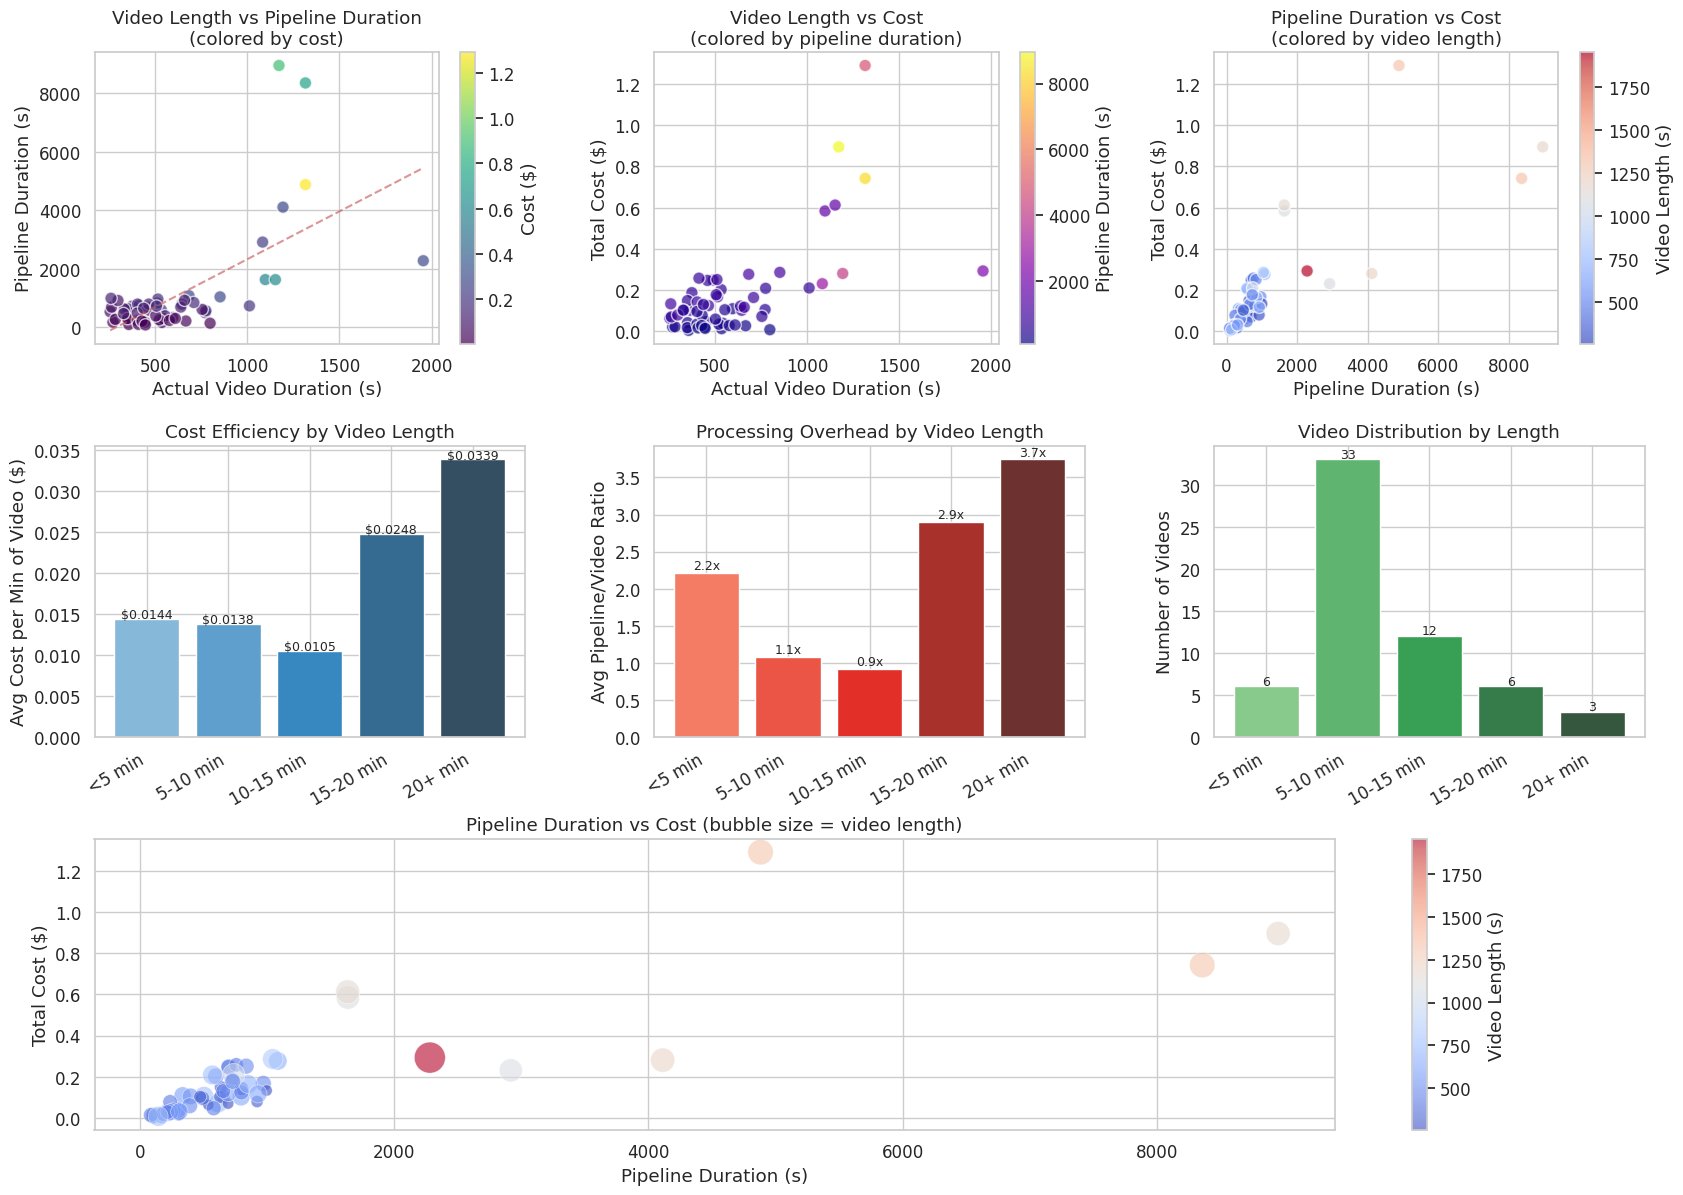


=== Summary ===
Correlation: Video Length vs Cost = 0.658
Correlation: Video Length vs Pipeline = 0.641
Correlation: Pipeline vs Cost = 0.804

Average cost per minute of video: $0.0153
Average pipeline time per minute of video: 88.8s


In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid", font_scale=1.1)
fig = plt.figure(figsize=(20, 14))
gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)

# 1. Scatter: Video length vs Pipeline duration (colored by cost)
ax1 = fig.add_subplot(gs[0, 0])
sc = ax1.scatter(df_full['actual_duration_s'], df_full['pipeline_duration_s'], 
                 c=df_full['cost_TOTAL'], cmap='viridis', s=80, alpha=0.7, edgecolors='white')
z = np.polyfit(df_full['actual_duration_s'], df_full['pipeline_duration_s'], 1)
p = np.poly1d(z)
x_line = np.linspace(df_full['actual_duration_s'].min(), df_full['actual_duration_s'].max(), 100)
ax1.plot(x_line, p(x_line), 'r--', alpha=0.6)
ax1.set_xlabel('Actual Video Duration (s)')
ax1.set_ylabel('Pipeline Duration (s)')
ax1.set_title('Video Length vs Pipeline Duration\n(colored by cost)')
plt.colorbar(sc, ax=ax1, label='Cost ($)')

# 2. Scatter: Video length vs Cost (colored by pipeline duration)
ax2 = fig.add_subplot(gs[0, 1])
sc2 = ax2.scatter(df_full['actual_duration_s'], df_full['cost_TOTAL'], 
                  c=df_full['pipeline_duration_s'], cmap='plasma', s=80, alpha=0.7, edgecolors='white')
ax2.set_xlabel('Actual Video Duration (s)')
ax2.set_ylabel('Total Cost ($)')
ax2.set_title('Video Length vs Cost\n(colored by pipeline duration)')
plt.colorbar(sc2, ax=ax2, label='Pipeline Duration (s)')

# 3. Scatter: Pipeline duration vs Cost (colored by video length)
ax3 = fig.add_subplot(gs[0, 2])
sc3 = ax3.scatter(df_full['pipeline_duration_s'], df_full['cost_TOTAL'], 
                  c=df_full['actual_duration_s'], cmap='coolwarm', s=80, alpha=0.7, edgecolors='white')
ax3.set_xlabel('Pipeline Duration (s)')
ax3.set_ylabel('Total Cost ($)')
ax3.set_title('Pipeline Duration vs Cost\n(colored by video length)')
plt.colorbar(sc3, ax=ax3, label='Video Length (s)')

# 4. Bar: Avg cost per minute by video length bucket
ax4 = fig.add_subplot(gs[1, 0])
bucket_order = ['<5 min', '5-10 min', '10-15 min', '15-20 min', '20+ min']
cost_per_min_by_bucket = df_full.groupby('duration_bucket')['cost_per_min_video'].mean().reindex(bucket_order)
bars = ax4.bar(range(len(bucket_order)), cost_per_min_by_bucket.values, color=sns.color_palette('Blues_d', len(bucket_order)))
ax4.set_xticks(range(len(bucket_order)))
ax4.set_xticklabels(bucket_order, rotation=30, ha='right')
ax4.set_ylabel('Avg Cost per Min of Video ($)')
ax4.set_title('Cost Efficiency by Video Length')
for i, v in enumerate(cost_per_min_by_bucket.values):
    if not np.isnan(v):
        ax4.text(i, v + 0.0001, f'${v:.4f}', ha='center', fontsize=9)

# 5. Bar: Avg pipeline ratio by video length bucket
ax5 = fig.add_subplot(gs[1, 1])
ratio_by_bucket = df_full.groupby('duration_bucket')['ratio_pipeline_to_actual'].mean().reindex(bucket_order)
bars = ax5.bar(range(len(bucket_order)), ratio_by_bucket.values, color=sns.color_palette('Reds_d', len(bucket_order)))
ax5.set_xticks(range(len(bucket_order)))
ax5.set_xticklabels(bucket_order, rotation=30, ha='right')
ax5.set_ylabel('Avg Pipeline/Video Ratio')
ax5.set_title('Processing Overhead by Video Length')
for i, v in enumerate(ratio_by_bucket.values):
    if not np.isnan(v):
        ax5.text(i, v + 0.05, f'{v:.1f}x', ha='center', fontsize=9)

# 6. Bar: Video count by bucket
ax6 = fig.add_subplot(gs[1, 2])
count_by_bucket = df_full.groupby('duration_bucket')['video_id'].count().reindex(bucket_order)
ax6.bar(range(len(bucket_order)), count_by_bucket.values, color=sns.color_palette('Greens_d', len(bucket_order)))
ax6.set_xticks(range(len(bucket_order)))
ax6.set_xticklabels(bucket_order, rotation=30, ha='right')
ax6.set_ylabel('Number of Videos')
ax6.set_title('Video Distribution by Length')
for i, v in enumerate(count_by_bucket.values):
    if not np.isnan(v):
        ax6.text(i, v + 0.2, f'{int(v)}', ha='center', fontsize=9)

# 7. 3D-like scatter: Video length vs Cost vs Pipeline (bubble chart)
ax7 = fig.add_subplot(gs[2, :])
sizes = np.clip(df_full['actual_duration_s'] / df_full['actual_duration_s'].max() * 500, 50, 500)
sc7 = ax7.scatter(df_full['pipeline_duration_s'], df_full['cost_TOTAL'], 
                  s=sizes, c=df_full['actual_duration_s'], cmap='coolwarm', alpha=0.6, edgecolors='white', linewidth=0.5)
ax7.set_xlabel('Pipeline Duration (s)')
ax7.set_ylabel('Total Cost ($)')
ax7.set_title('Pipeline Duration vs Cost (bubble size = video length)')
plt.colorbar(sc7, ax=ax7, label='Video Length (s)')

# # Add annotations for outliers
# for _, row in df_full.nlargest(5, 'cost_TOTAL').iterrows():
#     ax7.annotate(row['video_id'][:10], (row['pipeline_duration_s'], row['cost_TOTAL']), 
#                  fontsize=7, xytext=(5, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

print("\n=== Summary ===")
print(f"Correlation: Video Length vs Cost = {df_full['actual_duration_s'].corr(df_full['cost_TOTAL']):.3f}")
print(f"Correlation: Video Length vs Pipeline = {df_full['actual_duration_s'].corr(df_full['pipeline_duration_s']):.3f}")
print(f"Correlation: Pipeline vs Cost = {df_full['pipeline_duration_s'].corr(df_full['cost_TOTAL']):.3f}")
print(f"\nAverage cost per minute of video: ${df_full['cost_per_min_video'].mean():.4f}")
print(f"Average pipeline time per minute of video: {df_full['pipeline_per_min_video'].mean():.1f}s")

In [34]:
# Break down each pipeline stage's time by video length
timing_cols = [c for c in df.columns if c.startswith('timing_') and c != 'timing_Total']
stage_names = [c.replace('timing_', '') for c in timing_cols]

# Merge stage durations with video length
df_stages = df[['video_id'] + timing_cols].copy()
df_stages.columns = ['video_id'] + stage_names
df_stages = df_stages.merge(df_full[['video_id', 'actual_duration_s', 'duration_bucket']], on='video_id', how='inner')

bucket_order = ['<5 min', '5-10 min', '10-15 min', '15-20 min', '20+ min']

# 1. Mean stage duration by video length bucket
print("=== Mean Stage Duration (seconds) by Video Length ===")
stage_by_bucket = df_stages.groupby('duration_bucket')[stage_names].mean().reindex(bucket_order)
display(stage_by_bucket.round(1))

# 2. Stage duration as % of total pipeline time by bucket
print("\n=== Stage % of Total Pipeline Time by Video Length ===")
stage_pct_by_bucket = stage_by_bucket.div(df_stages.groupby('duration_bucket')['actual_duration_s'].mean().reindex(bucket_order), axis=0) * 100
display(stage_pct_by_bucket.round(1))

# 3. Correlation of each stage with video length
print("\n=== Correlation: Each Stage Duration vs Video Length ===")
stage_corrs = []
for stage in stage_names:
    r = df_stages['actual_duration_s'].corr(df_stages[stage])
    stage_corrs.append({'Stage': stage, 'Correlation': r})
df_corrs = pd.DataFrame(stage_corrs).sort_values('Correlation', ascending=False)
display(df_corrs.round(3))

# 4. Stage time per minute of video by bucket
print("\n=== Stage Seconds per Minute of Video (by bucket) ===")
bucket_avg_video_min = df_stages.groupby('duration_bucket')['actual_duration_s'].mean() / 60
stage_per_min = stage_by_bucket.div(bucket_avg_video_min, axis=0)
display(stage_per_min.round(1))

=== Mean Stage Duration (seconds) by Video Length ===


,Video Registration,Shot Detection,Video Preprocessing,ASR,Audio Segmentation,Segment Caption,Segment Embedding,Audio Transcript Embedding,Segment Qdrant Indexing,Audio Transcript Qdrant Indexing,...,Segment Caption Qdrant Indexing,Knowledge Graph Pipeline,ArangoDB Indexing,Image Extraction,Image Caption + OCR,Image Embedding,Image Qdrant Indexing,OCR Indexing,Image Caption Embedding,Image Caption Qdrant Indexing
duration_bucket,,,,,,,,,,,,,,,,,,,,,
<5 min,5.6,8.9,2.3,12.9,11.7,20.9,11.1,0.9,0.7,1.0,...,0.6,373.6,2.8,5.3,60.5,41.7,2.2,10.9,16.9,10.2
5-10 min,5.4,11.2,3.8,16.8,5.9,10.9,10.6,2.0,0.8,1.3,...,1.1,161.0,2.9,5.9,85.8,78.6,3.7,9.8,32.2,22.1
10-15 min,5.5,16.8,4.3,23.1,6.3,11.0,19.1,2.2,0.7,1.0,...,0.8,277.0,3.4,6.7,78.4,100.3,5.0,7.3,33.6,39.9
15-20 min,5.7,23.1,18.6,55.1,11.2,15.9,963.1,3.2,1.4,1.6,...,1.2,681.1,8.0,26.0,239.7,553.7,60.0,78.9,421.6,160.8
20+ min,5.6,28.2,31.9,93.2,18.8,11.5,950.6,6.3,1.6,1.7,...,1.3,867.8,12.0,44.6,500.7,944.5,127.1,153.3,756.8,613.8



=== Stage % of Total Pipeline Time by Video Length ===


,Video Registration,Shot Detection,Video Preprocessing,ASR,Audio Segmentation,Segment Caption,Segment Embedding,Audio Transcript Embedding,Segment Qdrant Indexing,Audio Transcript Qdrant Indexing,...,Segment Caption Qdrant Indexing,Knowledge Graph Pipeline,ArangoDB Indexing,Image Extraction,Image Caption + OCR,Image Embedding,Image Qdrant Indexing,OCR Indexing,Image Caption Embedding,Image Caption Qdrant Indexing
duration_bucket,,,,,,,,,,,,,,,,,,,,,
<5 min,2.0,3.3,0.9,4.7,4.3,7.7,4.1,0.3,0.3,0.4,...,0.2,137.4,1.0,2.0,22.3,15.3,0.8,4.0,6.2,3.7
5-10 min,1.2,2.5,0.8,3.8,1.3,2.4,2.4,0.4,0.2,0.3,...,0.3,35.9,0.6,1.3,19.1,17.5,0.8,2.2,7.2,4.9
10-15 min,0.8,2.4,0.6,3.2,0.9,1.5,2.7,0.3,0.1,0.1,...,0.1,38.8,0.5,0.9,11.0,14.1,0.7,1.0,4.7,5.6
15-20 min,0.5,2.1,1.7,4.9,1.0,1.4,86.1,0.3,0.1,0.1,...,0.1,60.9,0.7,2.3,21.4,49.5,5.4,7.1,37.7,14.4
20+ min,0.4,1.8,2.1,6.1,1.2,0.8,62.2,0.4,0.1,0.1,...,0.1,56.8,0.8,2.9,32.8,61.8,8.3,10.0,49.5,40.2



=== Correlation: Each Stage Duration vs Video Length ===


,Stage,Correlation
1,Shot Detection,0.800
3,ASR,0.673
2,Video Preprocessing,0.671
14,Image Extraction,0.632
16,Image Embedding,0.627
13,ArangoDB Indexing,0.610
17,Image Qdrant Indexing,0.569
18,OCR Indexing,0.546
15,Image Caption + OCR,0.525
20,Image Caption Qdrant Indexing,0.524



=== Stage Seconds per Minute of Video (by bucket) ===


,Video Registration,Shot Detection,Video Preprocessing,ASR,Audio Segmentation,Segment Caption,Segment Embedding,Audio Transcript Embedding,Segment Qdrant Indexing,Audio Transcript Qdrant Indexing,...,Segment Caption Qdrant Indexing,Knowledge Graph Pipeline,ArangoDB Indexing,Image Extraction,Image Caption + OCR,Image Embedding,Image Qdrant Indexing,OCR Indexing,Image Caption Embedding,Image Caption Qdrant Indexing
duration_bucket,,,,,,,,,,,,,,,,,,,,,
10-15 min,0.5,1.4,0.4,1.9,0.5,0.9,1.6,0.2,0.1,0.1,...,0.1,23.3,0.3,0.6,6.6,8.4,0.4,0.6,2.8,3.4
15-20 min,0.3,1.2,1.0,3.0,0.6,0.9,51.7,0.2,0.1,0.1,...,0.1,36.5,0.4,1.4,12.9,29.7,3.2,4.2,22.6,8.6
20+ min,0.2,1.1,1.3,3.7,0.7,0.5,37.3,0.2,0.1,0.1,...,0.1,34.1,0.5,1.7,19.7,37.1,5.0,6.0,29.7,24.1
5-10 min,0.7,1.5,0.5,2.3,0.8,1.5,1.4,0.3,0.1,0.2,...,0.2,21.5,0.4,0.8,11.5,10.5,0.5,1.3,4.3,3.0
<5 min,1.2,2.0,0.5,2.8,2.6,4.6,2.4,0.2,0.2,0.2,...,0.1,82.4,0.6,1.2,13.4,9.2,0.5,2.4,3.7,2.2


ValueError: The number of FixedLocator locations (21), usually from a call to set_ticks, does not match the number of labels (5).

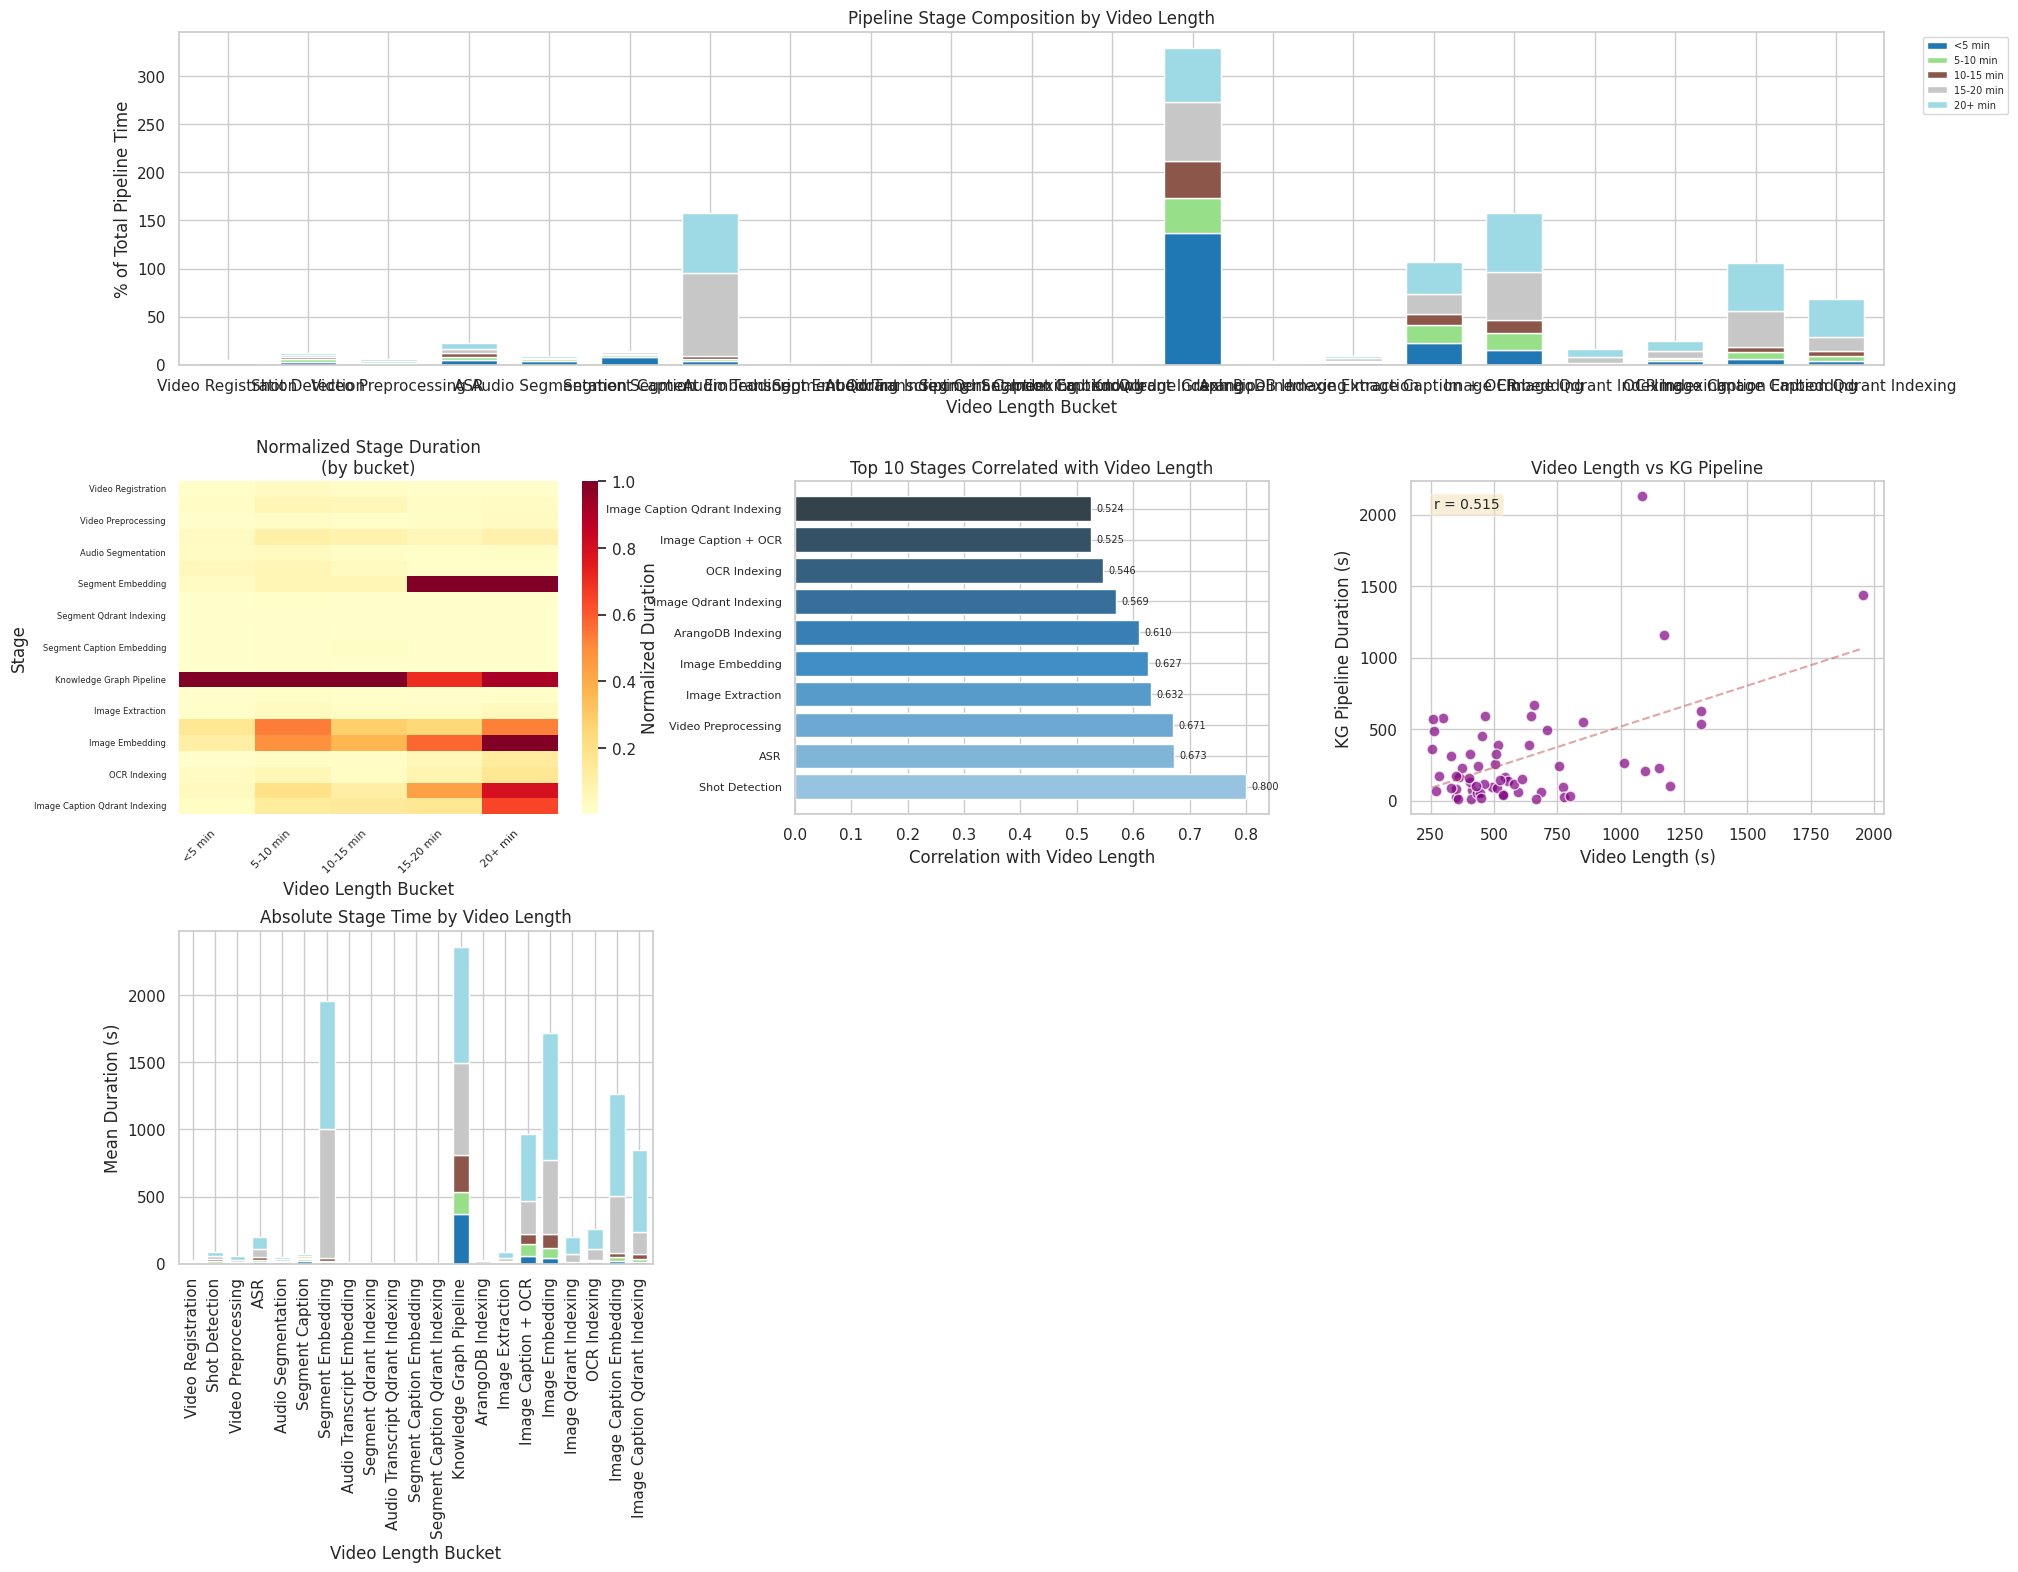

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid", font_scale=1.0)
fig = plt.figure(figsize=(22, 16))
gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)

# 1. Stacked bar: Stage composition by video length bucket
ax1 = fig.add_subplot(gs[0, :])
stage_pct_by_bucket.T.plot(kind='bar', stacked=True, ax=ax1, colormap='tab20', width=0.7)
ax1.set_xlabel('Video Length Bucket')
ax1.set_ylabel('% of Total Pipeline Time')
ax1.set_title('Pipeline Stage Composition by Video Length')
ax1.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=7)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=0)

# 2. Heatmap: Stage duration by bucket
ax2 = fig.add_subplot(gs[1, 0])
stage_by_bucket_norm = stage_by_bucket.div(stage_by_bucket.max(axis=1), axis=0)
sns.heatmap(stage_by_bucket_norm.T, annot=False, cmap='YlOrRd', ax=ax2, cbar_kws={'label': 'Normalized Duration'})
ax2.set_xlabel('Video Length Bucket')
ax2.set_ylabel('Stage')
ax2.set_title('Normalized Stage Duration\n(by bucket)')
ax2.set_xticklabels(bucket_order, rotation=45, ha='right', fontsize=8)
ax2.tick_params(axis='y', labelsize=6)

# 3. Horizontal bar: Top 10 stages correlated with video length
ax3 = fig.add_subplot(gs[1, 1])
top10_corr = df_corrs.head(10)
colors = sns.color_palette('Blues_d', len(top10_corr))
ax3.barh(range(len(top10_corr)), top10_corr['Correlation'].values, color=colors)
ax3.set_yticks(range(len(top10_corr)))
ax3.set_yticklabels(top10_corr['Stage'], fontsize=8)
ax3.set_xlabel('Correlation with Video Length')
ax3.set_title('Top 10 Stages Correlated with Video Length')
for i, v in enumerate(top10_corr['Correlation'].values):
    ax3.text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=7)

# 4. Scatter: Video length vs KG Pipeline duration
ax4 = fig.add_subplot(gs[1, 2])
ax4.scatter(df_stages['actual_duration_s'], df_stages['Knowledge Graph Pipeline'], s=60, alpha=0.7, color='purple', edgecolors='white')
z = np.polyfit(df_stages['actual_duration_s'], df_stages['Knowledge Graph Pipeline'], 1)
ax4.plot(np.linspace(df_stages['actual_duration_s'].min(), df_stages['actual_duration_s'].max(), 100),
         np.poly1d(z)(np.linspace(df_stages['actual_duration_s'].min(), df_stages['actual_duration_s'].max(), 100)), 'r--', alpha=0.5)
ax4.set_xlabel('Video Length (s)')
ax4.set_ylabel('KG Pipeline Duration (s)')
ax4.set_title('Video Length vs KG Pipeline')
ax4.text(0.05, 0.95, f'r = {df_stages["actual_duration_s"].corr(df_stages["Knowledge Graph Pipeline"]):.3f}',
         transform=ax4.transAxes, fontsize=10, va='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# 5. Stacked bar: Absolute stage time by bucket
ax5 = fig.add_subplot(gs[2, 0])
stage_by_bucket.T.plot(kind='bar', stacked=True, ax=ax5, colormap='tab20', width=0.7)
ax5.set_xlabel('Video Length Bucket')
ax5.set_ylabel('Mean Duration (s)')
ax5.set_title('Absolute Stage Time by Video Length')
ax5.legend_.remove()
ax5.set_xticklabels(bucket_order, rotation=0, fontsize=8)

# 6. Line: Stage seconds per minute of video by bucket (top 8 stages)
ax6 = fig.add_subplot(gs[2, 1])
top8_stages = stage_per_min.mean().nlargest(8).index.tolist()
for stage in top8_stages:
    ax6.plot(bucket_order, stage_per_min.loc[stage].values, marker='o', linewidth=2, label=stage)
ax6.set_xlabel('Video Length Bucket')
ax6.set_ylabel('Seconds per Min of Video')
ax6.set_title('Processing Intensity: Top 8 Stages')
ax6.legend(fontsize=6, loc='upper left')
ax6.tick_params(axis='x', rotation=45)

# 7. Scatter: Video length vs Total pipeline (with stage breakdown as stacked area concept)
ax7 = fig.add_subplot(gs[2, 2])
top5_stages_abs = stage_by_bucket.mean().nlargest(5).index.tolist()
for stage in top5_stages_abs:
    ax7.scatter(df_stages['actual_duration_s'], df_stages[stage], s=40, alpha=0.6, label=stage)

ax7.set_xlabel('Video Length (s)')
ax7.set_ylabel('Stage Duration (s)')
ax7.set_title('Top 5 Stages vs Video Length')
ax7.legend(fontsize=6)

plt.tight_layout()
plt.show()

print("\n=== Key Takeaways ===")
print(f"Stages most correlated with video length:")
for _, row in df_corrs.head(5).iterrows():
    print(f"  {row['Stage']}: r={row['Correlation']:.3f}")
print(f"\nStages least correlated with video length (fixed overhead):")
for _, row in df_corrs.tail(5).iterrows():
    print(f"  {row['Stage']}: r={row['Correlation']:.3f}")